<div align="center">

To: Alexis Diamond 

From: Undral Ganbaatar

</div>


# Introduction

This project explores two distinct applications of causal inference methods. The first part analyzes the effects of federally funded job training programs on earnings and employment using randomized experiments, observational data, matching techniques, and instrumental variables. The second part applies the synthetic control method to estimate the causal impact of California’s 2011–2015 drought on property and violent crime rates by constructing a counterfactual from unaffected U.S. states. 

# Original Lalonde Dataset
## Treatment Effect

Since this is a randomized control trial (RCT), we can estimate the Average Treatment Effect on the Treated (ATT) by simply calculating the difference in mean outcomes between the treatment and control groups. While the true treatment effect, as defined by the Rubin Causal Model, is the difference between potential outcomes for each individual (treated vs. untreated), we can’t observe both for the same person. This is known as the fundamental problem of causal inference.

Instead, we rely on randomization to ensure that the treatment and control groups are statistically equivalent, so any difference in outcomes can be attributed to the treatment. In this setup, the control group serves as a stand-in for the counterfactual outcomes the treated group would have experienced without the program. Therefore, what we’re estimating is the ATT, not the ATE.

We can run a linear regression on the outcome variable (re78, real earnings in 1978) with only the treatment variable (treat, participation in the National Supported Work program) as a predictor. The treatment effect is the coefficient of the treatment variable. 

In [8]:
# Load required packages
library(Matching)  
library(dplyr)      
library(quantreg)   
library(ggplot2)    

# Load the Lalonde experimental data
data(lalonde)
str(lalonde)
head(lalonde)

lm <- lm(re78 ~ treat, data = lalonde)
summary(lm)
confint(lm)

'data.frame':	445 obs. of  12 variables:
 $ age    : int  37 22 30 27 33 22 23 32 22 33 ...
 $ educ   : int  11 9 12 11 8 9 12 11 16 12 ...
 $ black  : int  1 0 1 1 1 1 1 1 1 0 ...
 $ hisp   : int  0 1 0 0 0 0 0 0 0 0 ...
 $ married: int  1 0 0 0 0 0 0 0 0 1 ...
 $ nodegr : int  1 1 0 1 1 1 0 1 0 0 ...
 $ re74   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ re75   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ re78   : num  9930 3596 24910 7506 290 ...
 $ u74    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ u75    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ treat  : int  1 1 1 1 1 1 1 1 1 1 ...


,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75,treat
,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
1,37,11,1,0,1,1,0,0,9930.05,1,1,1
2,22,9,0,1,0,1,0,0,3595.89,1,1,1
3,30,12,1,0,0,0,0,0,24909.50,1,1,1
4,27,11,1,0,0,1,0,0,7506.15,1,1,1
5,33,8,1,0,0,1,0,0,289.79,1,1,1
6,22,9,1,0,0,1,0,0,4056.49,1,1,1



Call:
lm(formula = re78 ~ treat, data = lalonde)

Residuals:
   Min     1Q Median     3Q    Max 
 -6349  -4555  -1829   2917  53959 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   4554.8      408.0  11.162  < 2e-16 ***
treat         1794.3      632.9   2.835  0.00479 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6580 on 443 degrees of freedom
Multiple R-squared:  0.01782,	Adjusted R-squared:  0.01561 
F-statistic: 8.039 on 1 and 443 DF,  p-value: 0.004788


,2.5 %,97.5 %
(Intercept),3752.8559,5356.749
treat,550.5749,3038.111


The point estimate of the treatment effect is 1794.3, with a confidence interval between 550.6 and 3038.1. We are 95% confident that the true average effect of the job training program lies within this range. The p-value of the coefficient is quite small (statistically significant, represents the probability of observing this extreme of a treatment effect by random chance). 

The results indicate that getting the treatment leads to 1794.3 dollars more in earnings. 

## Quantiles

In [9]:
# Quantile treatment effects [1%, 99%]
taus <- seq(0.01, 0.99, by = 0.01)

qte_list <- suppressWarnings(lapply(taus, function(tau) {
  rq_mod <- rq(re78 ~ treat, tau = tau, data = lalonde)
  rq_sum <- summary(rq_mod, se = "boot", R = 1000)
  coef_est <- rq_sum$coefficients["treat", "Value"]
  se_est   <- rq_sum$coefficients["treat", "Std. Error"]
  data.frame(
    tau      = tau,
    estimate = coef_est,
    ci_lower = coef_est - 1.96 * se_est,
    ci_upper = coef_est + 1.96 * se_est
  )
}))


qte_df <- bind_rows(qte_list)

# Compute the mean treatment effect for reference
mean_te <- with(lalonde,
  mean(re78[treat == 1]) - mean(re78[treat == 0])
)

# Create a new data frame for the horizontal line so it can be mapped
mean_te_df <- data.frame(y = mean_te)

# Separate treated and control groups
treated  <- lalonde$re78[lalonde$treat == 1]
control  <- lalonde$re78[lalonde$treat == 0]

# Compute unconditional quantile differences
uncond_qte <- data.frame(
  tau = taus,
  estimate = quantile(treated, taus) - quantile(control, taus)
)

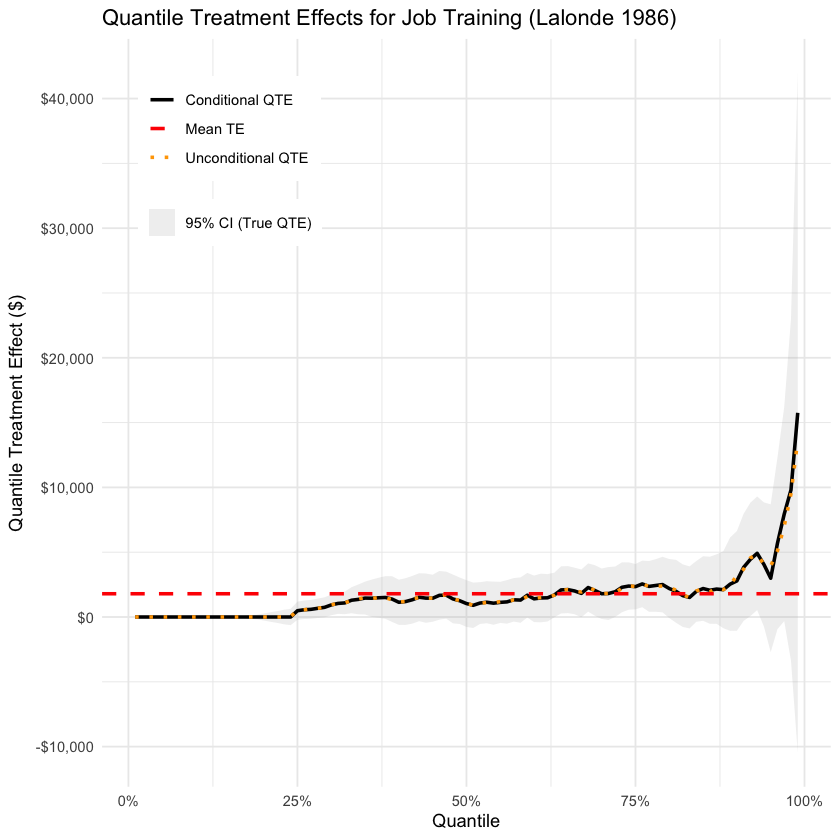

In [10]:
qte_df$ci_label <- "95% CI (True QTE)"

ggplot(qte_df, aes(x = tau, y = estimate)) +
  geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper, fill = ci_label), alpha = 0.2) +
  geom_line(aes(color = "Conditional QTE"), size = 1) +
  geom_line(data = uncond_qte, aes(x = tau, y = estimate, color = "Unconditional QTE"), size = 1, linetype = "dotted") +
  geom_hline(
    data = mean_te_df,
    aes(yintercept = y, color = "Mean TE"),
    linetype = "dashed",
    size = 1
  ) +
  scale_color_manual(
    values = c(
      "Conditional QTE" = "black",
      "Unconditional QTE" = "orange",
      "Mean TE" = "red"
    ),
    guide = guide_legend(title = NULL)
  ) +
  scale_fill_manual(
    values = c("95% CI (True QTE)" = "grey70"),
    guide = guide_legend(title = NULL)
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(
    x = "Quantile",
    y = "Quantile Treatment Effect ($)",
    title = "Quantile Treatment Effects for Job Training (Lalonde 1986)"
  ) +
  theme_minimal() +
  theme(
    legend.position = c(0.05, 0.95),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = "white", color = NA),
    legend.box.background = element_blank()
  )


In the bottom quartile (0–25%), the estimated treatment effect is close to zero, with little uncertainty, suggesting the program had no measurable impact on the lowest earners. Around the 25th percentile, the effect begins to rise and fluctuates near the average treatment effect through the middle of the distribution. Starting around the 88th percentile, the effect increases sharply and reaches its highest impact near the top of the earnings distribution. However, this region also shows greater uncertainty, as indicated by the wider confidence bands. The treatment seems to not work at all for the poor and work the best for the rich. 

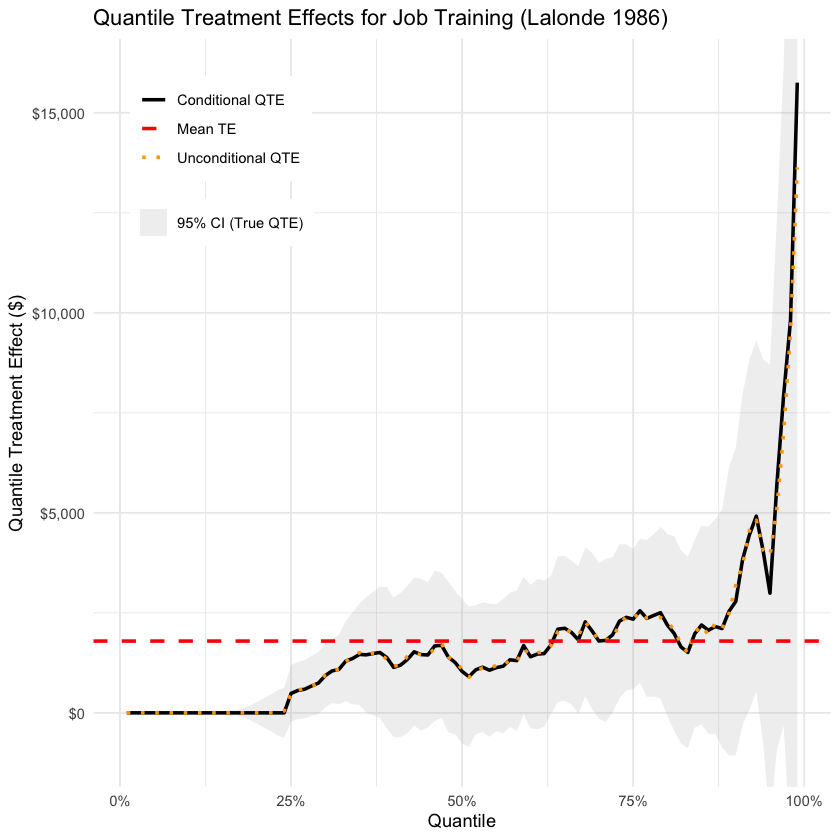

In [11]:
ggplot(qte_df, aes(x = tau, y = estimate)) +
  geom_ribbon(aes(ymin = ci_lower, ymax = ci_upper, fill = ci_label), alpha = 0.2) +
  geom_line(aes(color = "Conditional QTE"), size = 1) +
  geom_line(data = uncond_qte, aes(x = tau, y = estimate, color = "Unconditional QTE"), size = 1, linetype = "dotted") +
  geom_hline(
    data = mean_te_df,
    aes(yintercept = y, color = "Mean TE"),
    linetype = "dashed",
    size = 1
  ) +
  scale_color_manual(
    values = c(
      "Conditional QTE" = "black",
      "Unconditional QTE" = "orange",
      "Mean TE" = "red"
    ),
    guide = guide_legend(title = NULL)
  ) +
  scale_fill_manual(
    values = c("95% CI (True QTE)" = "grey70"),
    guide = guide_legend(title = NULL)
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_y_continuous(labels = scales::dollar_format()) +
  coord_cartesian(ylim = c(-1000, 16000)) +
  labs(
    x = "Quantile",
    y = "Quantile Treatment Effect ($)",
    title = "Quantile Treatment Effects for Job Training (Lalonde 1986)"
  ) +
  theme_minimal() +
  theme(
    legend.position = c(0.05, 0.95),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = "white", color = NA),
    legend.box.background = element_blank()
  )


This version of the plot clips the Y-axis to make variation easier to see. It compares conditional quantile treatment effects (from quantile regression, which models the effect of treatment at each conditional quantile of the outcome) with unconditional QTEs (the raw difference in quantiles between treated and control groups). The two curves appear quite similar, suggesting that conditioning on covariates doesn't meaningfully change the estimated treatment effect across the earnings distribution.

# Matching
In this section, we will use the observational version of the lalonde dataset. 

In [12]:
library(haven)

url <- "https://drive.google.com/uc?export=download&id=14jObEXThKXgpAXTY7c_3dc3xNucBZvd8"
cps2 <- read_dta(url)

## Combine the datasets

In [ ]:
# The datasets don't match exactly. I'm making sure they match by renaming some variables and adding u74 and u75.

cps2$u74 <- ifelse(cps2$re74 == 0, 1, 0)
cps2$u75 <- ifelse(cps2$re75 == 0, 1, 0)

# Uncomment these lines to rename the variables if you're running on a local computer

#cps2 <- cps2 %>%
#  rename(
#    educ   = education,
#    hisp   = hispanic,
#    nodegr = nodegree
#  )

head(cps2)
#str(cps2)

treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,45,11,0,0,1,1,21516.670,25243.551,25564.670,0,0
0,21,14,0,0,0,0,3175.971,5852.565,13496.080,0,0
0,38,12,0,0,1,0,23039.020,25130.760,25564.670,0,0
0,48,6,0,0,1,1,24994.369,25243.551,25564.670,0,0
0,18,8,0,0,1,1,1669.295,10727.610,9860.869,0,0
0,22,11,0,0,1,1,16365.760,18449.270,25564.670,0,0


tibble [15,992 x 12] (S3: tbl_df/tbl/data.frame)
 $ treat  : num [1:15992] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ age    : num [1:15992] 45 21 38 48 18 22 48 18 48 45 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ educ   : num [1:15992] 11 14 12 6 8 11 10 11 9 12 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ black  : num [1:15992] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ hisp   : num [1:15992] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ married: num [1:15992] 1 0 1 1 1 1 1 0 1 1 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ nodegr : num [1:15992] 1 0 0 1 1 1 1 1 1 0 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ re74   : num [1:15992] 21517 3176 23039 24994 1669 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ re75   : num [1:15992] 25244 5853 25131 25244 10728 ...
  ..- attr(*, "format.stata")= chr "%9.0g"
 $ re78   : num [1:15992] 25565 13496 25565 25565 9861 ...
  ..- attr(*, "format

In [14]:
# Filter for treated units only
lalonde_treat <- subset(lalonde, treat == 1)

# Combine CPS-2 controls and Lalonde treated group
combined_data <- rbind(lalonde_treat, cps2)

In [15]:
str(combined_data)
head(combined_data)

'data.frame':	16177 obs. of  12 variables:
 $ age    : num  37 22 30 27 33 22 23 32 22 33 ...
 $ educ   : num  11 9 12 11 8 9 12 11 16 12 ...
 $ black  : num  1 0 1 1 1 1 1 1 1 0 ...
 $ hisp   : num  0 1 0 0 0 0 0 0 0 0 ...
 $ married: num  1 0 0 0 0 0 0 0 0 1 ...
 $ nodegr : num  1 1 0 1 1 1 0 1 0 0 ...
 $ re74   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ re75   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ re78   : num  9930 3596 24910 7506 290 ...
 $ u74    : num  1 1 1 1 1 1 1 1 1 1 ...
 $ u75    : num  1 1 1 1 1 1 1 1 1 1 ...
 $ treat  : num  1 1 1 1 1 1 1 1 1 1 ...


,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75,treat
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,37,11,1,0,1,1,0,0,9930.05,1,1,1
2,22,9,0,1,0,1,0,0,3595.89,1,1,1
3,30,12,1,0,0,0,0,0,24909.50,1,1,1
4,27,11,1,0,0,1,0,0,7506.15,1,1,1
5,33,8,1,0,0,1,0,0,289.79,1,1,1
6,22,9,1,0,0,1,0,0,4056.49,1,1,1


## Selection Bias

group,n,mean_re74,mean_re75,pct_zero_re74,pct_zero_re75
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
CPS-2 Control,15992,14016.800,13650.804,11.96223,10.93047
Treated,185,2095.574,1532.056,70.81081,60.00000



	Welch Two Sample t-test

data:  re74 by group
t = 32.469, df = 200.68, p-value < 2.2e-16
alternative hypothesis: true difference in means between group CPS-2 Control and group Treated is not equal to 0
95 percent confidence interval:
 11197.25 12645.20
sample estimates:
mean in group CPS-2 Control       mean in group Treated 
                  14016.800                    2095.574 



	Welch Two Sample t-test

data:  re75 by group
t = 48.91, df = 220.97, p-value < 2.2e-16
alternative hypothesis: true difference in means between group CPS-2 Control and group Treated is not equal to 0
95 percent confidence interval:
 11630.44 12607.06
sample estimates:
mean in group CPS-2 Control       mean in group Treated 
                  13650.804                    1532.056 


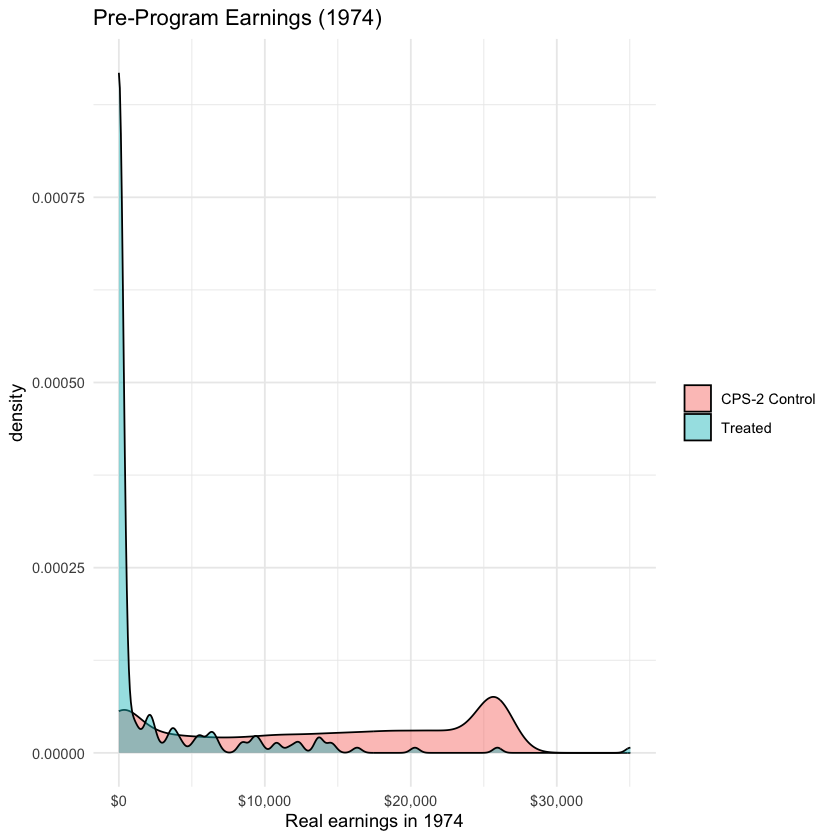

In [16]:
library(scales)
predata <- bind_rows(
  lalonde_treat %>% mutate(group = "Treated"),       
  cps2          %>% mutate(group = "CPS-2 Control") 
)
predata %>% 
  group_by(group) %>% 
  summarise(
    n             = n(),
    mean_re74     = mean(re74, na.rm = TRUE),
    mean_re75     = mean(re75, na.rm = TRUE),
    pct_zero_re74 = mean(re74 == 0) * 100,
    pct_zero_re75 = mean(re75 == 0) * 100,
    .groups = "drop"
  )

t.test(re74 ~ group, data = predata)   
t.test(re75 ~ group, data = predata)
ggplot(predata, aes(re74, fill = group)) +
  geom_density(alpha = 0.45) +
  scale_x_continuous(labels = dollar_format()) +
  labs(
    title = "Pre-Program Earnings (1974)",
    x     = "Real earnings in 1974",
    fill  = NULL
  ) +
  theme_minimal()

The comparison between the NSW treatment group and the CPS‑2 controls reveals strong evidence of selection bias, as expected. The CPS-2 controls come from the higher‑earning part of the population while the trainees are economically worse off up front. This asymmetry produces a negative selection bias in the estimated program effect: any simple comparison will understate, or even reverse, the true impact of the job‑training program because the “healthy” controls would have earned more even without training.

## Prima Facie Treatment Effect

In [17]:
mean_treat  <- mean(lalonde_treat$re78, na.rm = TRUE)
mean_cps2   <- mean(cps2$re78,         na.rm = TRUE)
naive_diff  <- mean_treat - mean_cps2 

cat("Estimated mean earnings in 1978:\n")
cat("  NSW Treated Group      :", round(mean_treat, 2), "\n")
cat("  CPS-2 Control Group     :", round(mean_cps2, 2), "\n")
cat("  Naive Difference (Treated - Control):", round(naive_diff, 2), "\n")


Estimated mean earnings in 1978:
  NSW Treated Group      : 6349.15 
  CPS-2 Control Group     : 14846.66 
  Naive Difference (Treated - Control): -8497.51 


The estimated mean earnings in 1978 for the NSW treated group is $6,349.15, while the CPS‑2 control group has a much higher mean of $14,846.66. The naive difference between the two groups is -$8,497.51. This is very different from the result in Part I where we used experimental controls and found a positive treatment effect. It also connects to what we saw in Part 2 which was that the CPS‑2 controls had much higher earnings before the program. The negative effect here is likely due to that selection bias.

## Propensity Score Matching

In [18]:
## Fit a propensity score model on combined_data
ps_mod <- glm(
  treat ~ educ + age + married + black + hisp + nodegr + re74 + re75 + u74 + u75,
  data   = combined_data,
  family = binomial
)

## Match on the log‑odds (link scale)
ps_link    <- predict(ps_mod, type = "link")
match_link <- Match(
  Tr = combined_data$treat,
  X  = ps_link,
  Y  = combined_data$re78
)
summary(match_link)



Estimate...  1043.2 
AI SE......  944.87 
T-stat.....  1.1041 
p.val......  0.26955 

Original number of observations..............  16177 
Original number of treated obs...............  185 
Matched number of observations...............  185 
Matched number of observations  (unweighted).  878 



In [19]:
## Match on the response (probability) scale
ps_resp    <- predict(ps_mod, type = "response")
match_resp <- Match(
  Tr = combined_data$treat,
  X  = ps_resp,
  Y  = combined_data$re78
)
summary(match_resp)


Estimate...  1322.1 
AI SE......  943.41 
T-stat.....  1.4014 
p.val......  0.16108 

Original number of observations..............  16177 
Original number of treated obs...............  185 
Matched number of observations...............  185 
Matched number of observations  (unweighted).  5180 



I used a logistic regression model to estimate propensity scores using all baseline covariates. I performed matching twice: once on the linear logit scale and once on the predicted response probabilities. The link scale uses the raw log-odds from the logistic regression, while the response scale uses the predicted probability of treatment. In both cases I used Sekhon's Match() function and estimated the Average Treatment Effect on the Treated (ATT). Controls are used just to estimate what the treated units would have earned without treatment, therefore the result is an estimate of ATT, not ATE.

The ATT estimate using the logit scale was $1,043.20 with a p-value of 0.27. The ATT from matching on the response scale was $1,322.10 with a p-value of 0.16. They both underestimate the true ATT from the RCT, but matching on the response scale gave a slightly larger and more statistically significant result. It also matched a lot more control observations (5180 vs 878).

In [ ]:
## Balance check for link match
mb_link <- invisible(MatchBalance(
  treat ~ educ + age + married + black + hisp + nodegr + re74 + re75 + u74 + u75,
  data      = combined_data,
  match.out = match_link,
  nboots    = 1000
))

#mb_link$AMsmallest.p.value
#mb_link$AMsmallestVarName
#head(data.frame(
#  Variable = mb_link$AMsmallestVarName,
#  P_Value  = mb_link$AMsmallest.p.value
#), 5)


***** (V1) educ *****
                       Before Matching 	 	 After Matching
mean treatment........     10.346 	 	     10.346 
mean control..........     12.028 	 	     10.481 
std mean diff.........    -83.633 	 	    -6.7123 

mean raw eQQ diff.....     1.7351 	 	    0.63554 
med  raw eQQ diff.....          2 	 	          0 
max  raw eQQ diff.....          4 	 	          4 

mean eCDF diff........   0.090791 	 	   0.033449 
med  eCDF diff........   0.037581 	 	   0.018223 
max  eCDF diff........    0.41227 	 	    0.11276 

var ratio (Tr/Co).....    0.49052 	 	    0.56177 
T-test p-value........ < 2.22e-16 	 	    0.53076 
KS Bootstrap p-value.. < 2.22e-16 	 	 < 2.22e-16 
KS Naive p-value...... < 2.22e-16 	 	 2.8383e-05 
KS Statistic..........    0.41227 	 	    0.11276 


***** (V2) age *****
                       Before Matching 	 	 After Matching
mean treatment........     25.816 	 	     25.816 
mean control..........     33.225 	 	     25.335 
std mean diff.........    -103.55 	

[1] "MatchBalance computed."

In [21]:
## Balance check for response match
mb_resp <- MatchBalance(
  treat ~ educ + age + married + black + hisp + nodegr + re74 + re75 + u74 + u75,
  data      = combined_data,
  match.out = match_resp,
  nboots    = 1000
)
mb_resp$AMsmallest.p.value
mb_resp$AMsmallestVarName


***** (V1) educ *****
                       Before Matching 	 	 After Matching
mean treatment........     10.346 	 	     10.346 
mean control..........     12.028 	 	     10.445 
std mean diff.........    -83.633 	 	    -4.9393 

mean raw eQQ diff.....     1.7351 	 	      1.445 
med  raw eQQ diff.....          2 	 	          1 
max  raw eQQ diff.....          4 	 	          8 

mean eCDF diff........   0.090791 	 	   0.076052 
med  eCDF diff........   0.037581 	 	   0.051931 
max  eCDF diff........    0.41227 	 	    0.20174 

var ratio (Tr/Co).....    0.49052 	 	    0.53949 
T-test p-value........ < 2.22e-16 	 	      0.651 
KS Bootstrap p-value.. < 2.22e-16 	 	 < 2.22e-16 
KS Naive p-value...... < 2.22e-16 	 	 < 2.22e-16 
KS Statistic..........    0.41227 	 	    0.20174 


***** (V2) age *****
                       Before Matching 	 	 After Matching
mean treatment........     25.816 	 	     25.816 
mean control..........     33.225 	 	     25.452 
std mean diff.........    -103.55 	

[1] 0

[1] "educ" "age"  "re74" "re75"

In terms of balance, both methods failed to fully balance the non-binary variables. The minimum p-values after matching were below 2.22e-16 in both cases, and the worst-matched covariates included educ, age, re74, and re75. The balance checks rely on the KS (Kolmogorov-Smirnov) bootstrap p-value, not the usual t-test p-value for the non-binary variables. KS is more sensitive to differences in the shape of the distribution, not just the mean. That’s helpful here because matching should ideally balance the full distribution of each covariate, not just its average, which is why we care more about the KS result when assessing covariate balance.

In [22]:
pairs_link <- data.frame(
  treated = match_link$index.treated,
  control = match_link$index.control
)
pairs_resp <- data.frame(
  treated = match_resp$index.treated,
  control = match_resp$index.control
)

common_pairs <- inner_join(pairs_link, pairs_resp, by = c("treated", "control"))
common_count <- nrow(common_pairs)
cat("Number of identical treated-control pairs in both matches:", common_count, "\n")

Number of identical treated-control pairs in both matches: 707 


Out of 878 total matched pairs in the log-odds match and 5,180 in the response match, 707 treated-control pairs are exactly the same in both. Even though the two approaches use different matching scales, a large portion of the log-odds matches overlap.

## Genetic Matching

In [23]:
library(rgenoud)

# Prepare combined data
Tr <- combined_data$treat
X  <- as.matrix(combined_data[, c("educ","age","married","black","hisp",
                                  "nodegr","re74","re75","u74","u75")])
Y  <- combined_data$re78

# Run genetic matching (default fitness)
set.seed(2025)
genout <- GenMatch(
  Tr       = Tr,
  X        = X,
  pop.size = 100,         
  max.generations = 10   
)

# Estimate ATT with the genetic weights
mout_gen <- Match(
  Tr            = Tr,
  X             = X,
  Weight.matrix = genout,
  Y             = Y
)
summary(mout_gen)

# Check balance after genetic matching
mb_gen <- MatchBalance(
  treat ~ educ + age + married + black + hisp + nodegr + re74 + re75 + u74 + u75,
  match.out = mout_gen,
  nboots    = 1000,
  data      = combined_data
)
#mb_gen$AMsmallest.p.value
#mb_gen$AMsmallestVarName
head(data.frame(
  Variable = mb_gen$AMsmallestVarName,
  P_Value  = mb_gen$AMsmallest.p.value
), 5)

##  rgenoud (Version 5.9-0.11, Build Date: 2024-10-03)
##  See http://sekhon.berkeley.edu/rgenoud for additional documentation.
##  Please cite software as:
##   Walter Mebane, Jr. and Jasjeet S. Sekhon. 2011.
##   ``Genetic Optimization Using Derivatives: The rgenoud package for R.''
##   Journal of Statistical Software, 42(11): 1-26. 
##






Wed Apr 23 17:17:49 2025
Domains:
 0.000000e+00   <=  X1   <=    1.000000e+03 
 0.000000e+00   <=  X2   <=    1.000000e+03 
 0.000000e+00   <=  X3   <=    1.000000e+03 
 0.000000e+00   <=  X4   <=    1.000000e+03 
 0.000000e+00   <=  X5   <=    1.000000e+03 
 0.000000e+00   <=  X6   <=    1.000000e+03 
 0.000000e+00   <=  X7   <=    1.000000e+03 
 0.000000e+00   <=  X8   <=    1.000000e+03 
 0.000000e+00   <=  X9   <=    1.000000e+03 
 0.000000e+00   <=  X10  <=    1.000000e+03 

Data Type: Floating Point
Operators (code number, name, population) 
	(1) Cloning........................... 	15
	(2) Uniform Mutation.................. 	12
	(3) Boundary Mutation................. 	12
	(4) Non-Uniform Mutation.............. 	12
	(5) Polytope Crossover................ 	12
	(6) Simple Crossover.................. 	12
	(7) Whole Non-Uniform Mutation........ 	12
	(8) Heuristic Crossover............... 	12
	(9) Local-Minimum Crossover........... 	0

SOFT Maximum Number of Generations: 10
Maximum N

,Variable,P_Value
,<chr>,<dbl>
1,age,0.224


In [24]:
# Pull out the ATT and the AI standard error
att_gen  <- mout_gen$est    
se_ai     <- mout_gen$se      

# Compute t and p using the AI SE
t_gen     <- att_gen / se_ai 
p_gen     <- 2 * (1 - pnorm(abs(t_gen))) 

cat(
  "Genetic Matching ATT =", round(att_gen,1), 
  "(AI SE =", round(se_ai,1), 
  ", t =", round(t_gen,3), 
  ", p =", round(p_gen,5), ")\n"
)


Genetic Matching ATT = 1804.6 (AI SE = 998.7 , t = 1.807 , p = 0.07077 )


I used genetic matching to improve covariate balance while retaining all 185 treated units. The algorithm optimized weights for each covariate to minimize imbalance. The resulting ATT was $1,804.6 with an Abadie-Imbens standard error of $998.7, giving a t‑stat of 1.807 and a p-value of 0.071. Compared to the earlier propensity score matches, this estimate is much closer to the true ATT and is statistically significant. 

Balance improved a lot. Before matching, non-binary covariates had large differences between groups, with minimum p-values below 2.22e-16. After matching, the worst imbalance was for age, but even that had a KS p-value of 0.224. Binary variables like black, married, nodegr, u74, and u75 matched perfectly.

## Quantile Effects for Genetic Matching

In [25]:
# Extract the genetically matched sample
matched_indices <- c(mout_gen$index.treated, mout_gen$index.control)
matched_data    <- combined_data[matched_indices, ]

# Estimate quantile treatment effects on matched_data
qte_matched_list <- lapply(taus, function(tau) {
  rq_mod  <- rq(re78 ~ treat, tau = tau, data = matched_data)
  rq_sum  <- summary(rq_mod, se = "boot", R = 500)
  coef    <- rq_sum$coefficients["treat", "Value"]
  se      <- rq_sum$coefficients["treat", "Std. Error"]
  data.frame(
    tau      = tau,
    estimate = coef,
    ci_lower = coef - 1.96 * se,
    ci_upper = coef + 1.96 * se
  )
})
qte_matched_df <- bind_rows(qte_matched_list)


Warning message in rq.fit.br(x, y, tau = tau, ...):
"Solution may be nonunique"


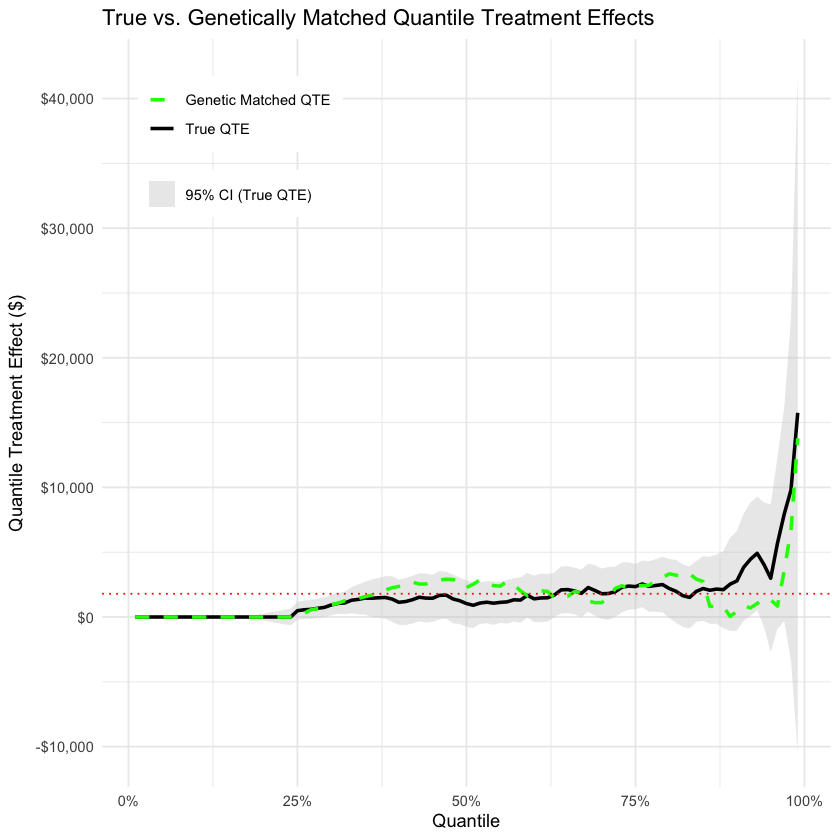

In [26]:
ggplot() +
  # True experimental QTE with confidence interval
  geom_ribbon(data = qte_df,
              aes(x = tau, ymin = ci_lower, ymax = ci_upper, fill = ci_label),
              alpha = 0.4) +
  geom_line(data = qte_df,
            aes(x = tau, y = estimate, color = "True QTE"),
            size = 1) +
  # Matched observational QTE
  geom_line(data = qte_matched_df,
            aes(x = tau, y = estimate, color = "Genetic Matched QTE"),
            size = 1, linetype = "dashed") +
  # Horizontal line at mean ATT
  geom_hline(yintercept = mean_te, linetype = "dotted", color = "red") +
  scale_color_manual(
    values = c("True QTE" = "black", "Genetic Matched QTE" = "green"),
    guide = guide_legend(title = NULL)
  ) +
  scale_fill_manual(
    values = c("95% CI (True QTE)" = "grey80"),
    guide = guide_legend(title = NULL)
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(
    x     = "Quantile",
    y     = "Quantile Treatment Effect ($)",
    title = "True vs. Genetically Matched Quantile Treatment Effects"
  ) +
  theme_minimal() +
  theme(
    legend.position = c(0.05, 0.95),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = "white", color = NA),
    legend.box.background = element_blank()
  )

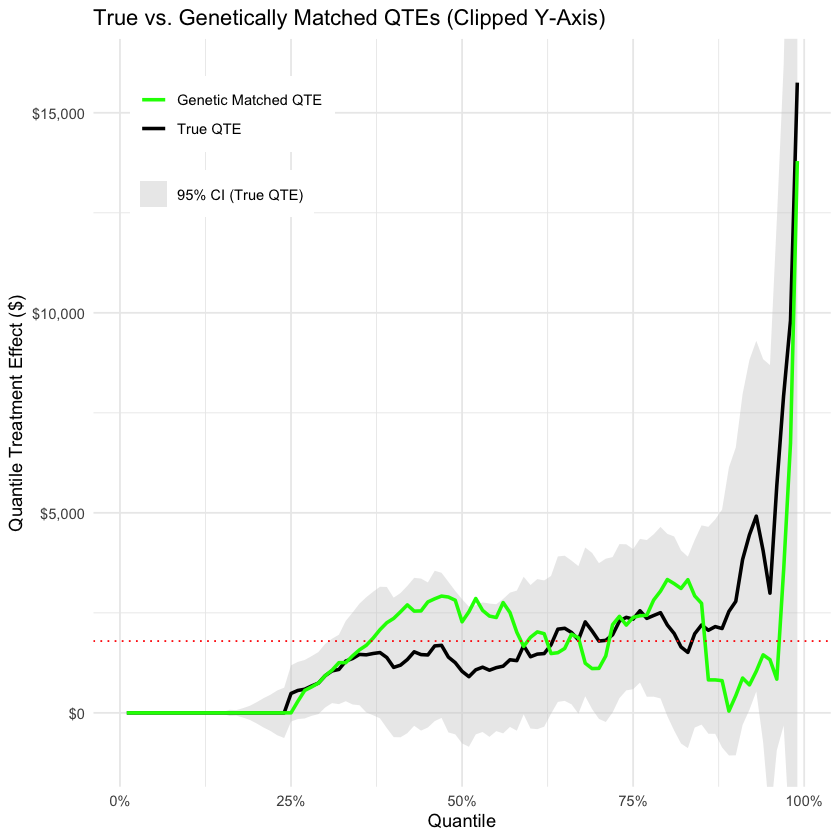

In [27]:
ggplot() +
  # True experimental QTE with confidence interval
  geom_ribbon(data = qte_df,
              aes(x = tau, ymin = ci_lower, ymax = ci_upper, fill = ci_label),
              alpha = 0.4) +
  geom_line(data = qte_df,
            aes(x = tau, y = estimate, color = "True QTE"),
            size = 1) +
  # Matched observational QTE
  geom_line(data = qte_matched_df,
            aes(x = tau, y = estimate, color = "Genetic Matched QTE"),
            size = 1) +
  # Horizontal line at mean ATT
  geom_hline(yintercept = mean_te, linetype = "dotted", color = "red") +
  # Clip y-axis
  coord_cartesian(ylim = c(-1000, 16000)) +
  scale_color_manual(
    values = c("True QTE" = "black", "Genetic Matched QTE" = "green"),
    guide = guide_legend(title = NULL)
  ) +
  scale_fill_manual(
    values = c("95% CI (True QTE)" = "grey80"),
    guide = guide_legend(title = NULL)
  ) +
  scale_x_continuous(labels = scales::percent_format(accuracy = 1)) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(
    x     = "Quantile",
    y     = "Quantile Treatment Effect ($)",
    title = "True vs. Genetically Matched QTEs (Clipped Y-Axis)"
  ) +
  theme_minimal() +
  theme(
    legend.position = c(0.05, 0.95),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = "white", color = NA),
    legend.box.background = element_blank()
  )


Across the distribution, the genetic‑matched curve stays almost entirely within the RCT’s 95 % confidence bands. It nails the effect in the bottom 30 %, then overshoots between the 30th and 62.5th percentiles, dips just below the true effect up to the 70th percentile, overshoots again from roughly 75 % to 87.5 %, and then underestimates more severely to the 99th percentile. However, it still spikes at the very top, mirroring the true QTE’s jump near the 100 % tail. Although there are pockets of over‑ and under‑estimation, there’s no consistent bias, and nearly every matched estimate lies within the experimental confidence interval, meaning our genetic matching has captured the true distributional impact within its uncertainty bounds.

## Sensitivity to Hidden Bias

In [28]:
vars <- c("educ","age","married","black","hisp","nodegr","re74","re75","u74","u75")

# Compute correlations with the outcome
cors <- sapply(matched_data[vars], function(v) cor(v, matched_data$re78, use = "complete.obs"))

# Sort by absolute correlation
data.frame(
  predictor   = vars,
  correlation = cors,
  abs_cor     = abs(cors)
) %>%
  arrange(desc(abs_cor))


,predictor,correlation,abs_cor
,<chr>,<dbl>,<dbl>
re75,re75,0.23078214,0.23078214
re74,re74,0.15874498,0.15874498
u75,u75,-0.14698828,0.14698828
married,married,0.13089535,0.13089535
educ,educ,0.11791257,0.11791257
u74,u74,-0.07053148,0.07053148
black,black,-0.06978839,0.06978839
nodegr,nodegr,-0.06931924,0.06931924
hisp,hisp,0.06235920,0.06235920


1975 earnings are correlated the most with the response variable, after matching. I'll use this as a benchmark since it is the strongest predictor. 

In [29]:
# install.packages("sensemakr")
library(sensemakr)

# fit the “analysis” regression including all covariates
lm_gen <- lm(
  re78 ~ treat
    + educ + age + married + black + hisp + nodegr
    + re74  + re75 + u74 + u75,
  data = matched_data
)

# run sensemakr benchmarking on re75
sm_gen <- sensemakr(
  model                = lm_gen,
  treatment            = "treat",
  benchmark_covariates = "re75",
  kd                   = 1:8,   
  ky                   = 1:8     
)
#summary(sm_gen)
head(sm_gen$benchmarks, 5)
sm_gen$robustness_values



See details in:

Carlos Cinelli and Chad Hazlett (2020). Making Sense of Sensitivity: Extending Omitted Variable Bias. Journal of the Royal Statistical Society, Series B (Statistical Methodology).



NULL

NULL

Once I control for the covariates, the treatment coefficient is about $1790 (SE ≈ $570), with a t‐value of 3.14. The partial R² of treat in that regression is only 2.05 percent. In other words, after adjusting for everything else, ‘treat’ still explains about two cents of every dollar of residual variation in 1978 earnings.

Sensemakr’s “robustness value” for moving the point estimate all the way to zero is R² ≈ 13.5 percent. Concretely, an omitted variable that is orthogonal to all the covariates and that explains 13.5 percent of the residual variance in both treatment status and earnings would just be strong enough to knock our $1 790 effect down to zero. Anything weaker than that simply can’t generate enough bias.

The robustness value for losing statistical significance at α = 0.05 is R² ≈ 5.3 percent. So any hidden confounder that explained less than about 5 percent of the leftover variation in both treat and re78 would not only fail to zero out the point estimate, it would also leave the t‐statistic above 2.

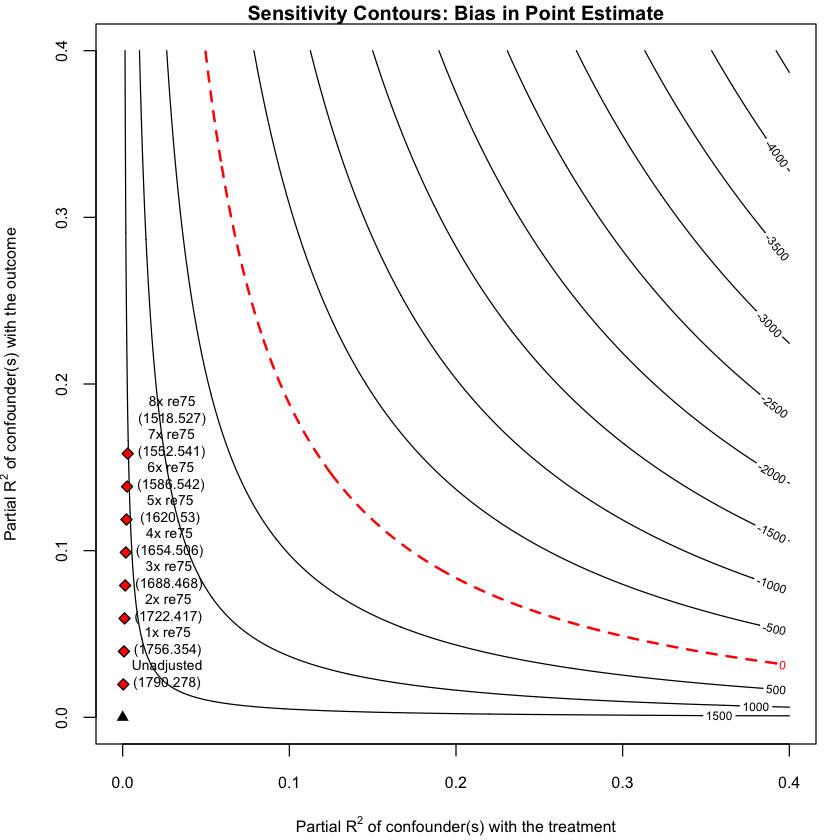

In [30]:
# Contour of point‐estimate bias
p1 <- plot(
  sm_gen,
  main = "Sensitivity Contours: Bias in Point Estimate",
)


Because re75, even though it’s our strongest observed predictor, only explains a tiny portion of variance, multiplying its partial R² by eight still falls well short of the R²–levels required to wipe out the $1,790 point estimate. In other words, we’d need a truly enormous confounder, one that is many, many times stronger than anything that's measured to explain away the program’s effect. 

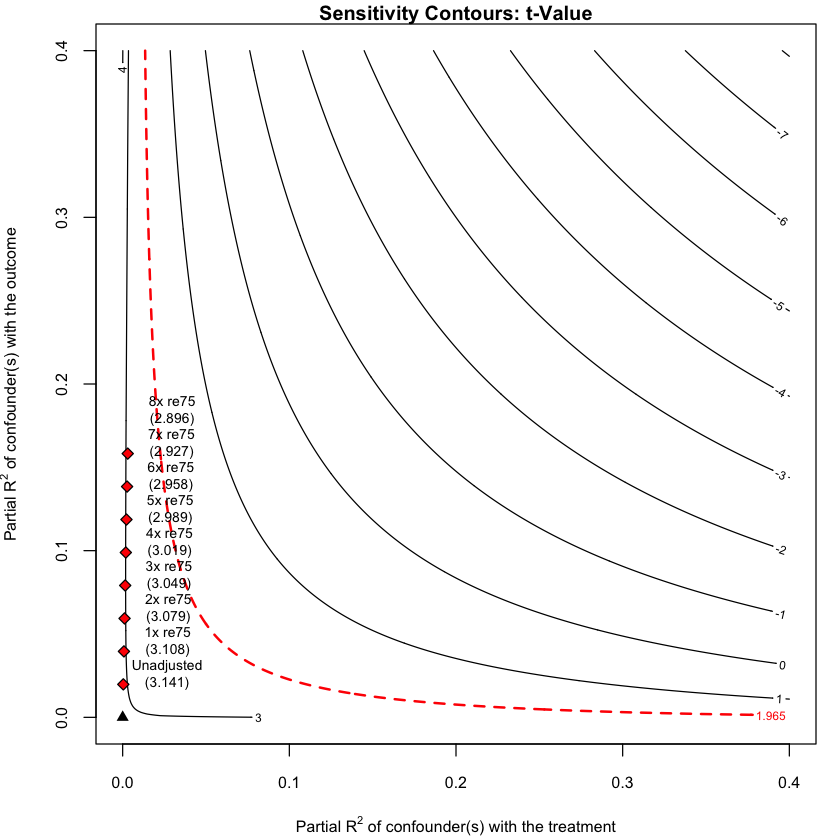

In [31]:
# Contour for t‐value (statistical significance)
p2 <- plot(
  sm_gen,
  sensitivity.of = "t-value",
  main = "Sensitivity Contours: t-Value",
)


A hypothetical variable that is 8 times stronger than re75 doesn't make the treatment effect statistically insignificant. 

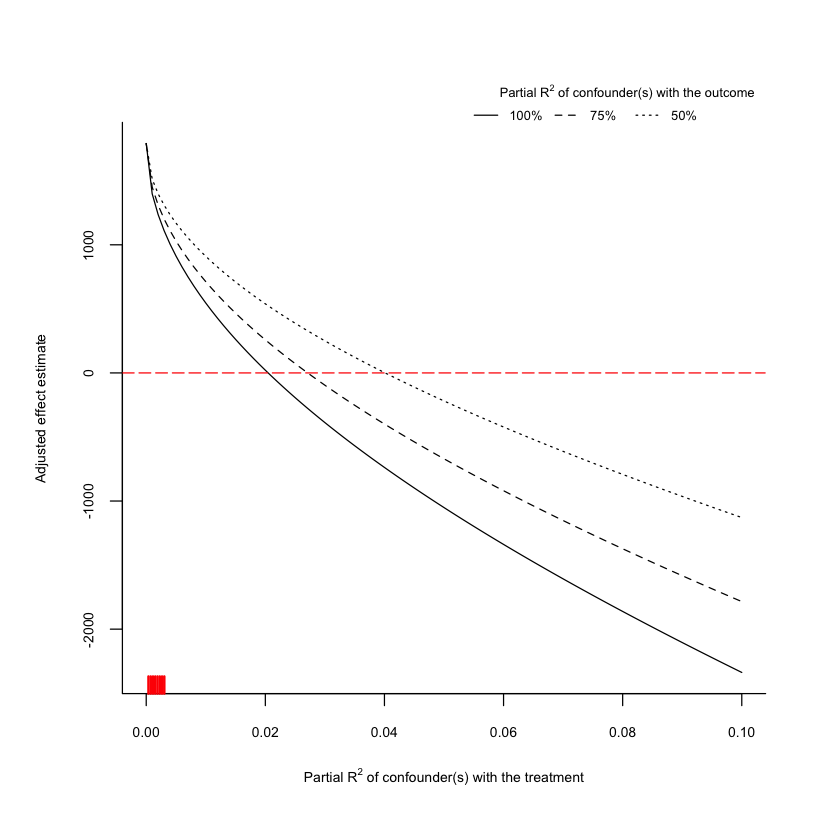

In [32]:
# “Extreme” scenario: assume confounder explains 100%, 75%, 50% of Y‐variance
plot(
  sm_gen,
  type        = "extreme"
)



This last plot shows a worst-case scenario where we imagine a hidden variable that explains 100%, 75%, or 50% of the leftover variation in 1978 earnings. The lines show how strong that variable would also need to be at predicting treatment to erase the observed treatment effect.

The red bar shows how well re75, our strongest observed covariate, predicts treatment. Even if an unobserved variable were 8 times as strong as re75 and explained nearly all of the outcome variance, it still wouldn't be enough to make the treatment effect disappear. So the ATT estimate looks pretty robust.

# Encouragement Design and JTPA Data

The National Job Training Partnership Act (JTPA) Study is a large-scale randomized evaluation conducted in the late 1980s to assess the effectiveness of federally funded job training programs in the U.S. Over 20,000 individuals were randomly assigned to either a program group (eligible for training) or a control group (ineligible for 18 months). The dataset includes demographic information, training participation, and labor market outcomes like earnings and unemployment duration.

## Unemployment Duration & Earnings

In [33]:
jtpa_data <- read.csv("https://raw.githubusercontent.com/GillesCrommen/DCC/refs/heads/main/clean_dataset_JTPA.csv")
head(jtpa_data)
str(jtpa_data)
summary(jtpa_data)

,recid,age,hsged,white,children,jtpa,married,male,treatment,delta,days
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,300001,46,1,0,0,1,0,0,1,1,151
2,300002,24,1,1,1,1,0,0,1,1,32
3,300003,28,0,0,1,1,1,1,1,1,72
4,300006,34,1,0,1,0,1,0,1,1,188
5,300008,31,1,1,1,1,0,0,1,1,68
6,300009,21,1,0,0,1,0,1,1,1,140


'data.frame':	10928 obs. of  11 variables:
 $ recid    : int  300001 300002 300003 300006 300008 300009 300011 300014 300015 300016 ...
 $ age      : int  46 24 28 34 31 21 20 41 24 26 ...
 $ hsged    : int  1 1 0 1 1 1 1 1 0 1 ...
 $ white    : int  0 1 0 0 1 0 1 1 1 1 ...
 $ children : int  0 1 1 1 1 0 0 1 1 0 ...
 $ jtpa     : int  1 1 1 0 1 1 1 1 1 1 ...
 $ married  : int  0 0 1 1 0 0 0 1 1 0 ...
 $ male     : int  0 0 1 0 0 1 1 0 1 1 ...
 $ treatment: int  1 1 1 1 1 1 1 1 1 1 ...
 $ delta    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ days     : int  151 32 72 188 68 140 44 174 212 66 ...


     recid             age            hsged            white       
 Min.   :300001   Min.   :16.00   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:305128   1st Qu.:20.00   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :310282   Median :26.00   Median :0.0000   Median :1.0000  
 Mean   :310286   Mean   :28.73   Mean   :0.4808   Mean   :0.5633  
 3rd Qu.:315392   3rd Qu.:34.00   3rd Qu.:1.0000   3rd Qu.:1.0000  
 Max.   :320602   Max.   :82.00   Max.   :1.0000   Max.   :1.0000  
    children           jtpa           married            male       
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :0.0000   Median :1.0000   Median :0.0000   Median :0.0000  
 Mean   :0.4922   Mean   :0.5025   Mean   :0.2254   Mean   :0.4268  
 3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:0.0000   3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000   Max.   :1.0000  
   treatment          delta             d

In [34]:
# Effect of encouragement on treatment take-up
encouraged_treated <- mean(jtpa_data$treatment[jtpa_data$jtpa == 1])
control_treated <- mean(jtpa_data$treatment[jtpa_data$jtpa == 0])
compliance_rate <- encouraged_treated - control_treated
# ITT: Effect of encouragement on outcome (days unemployed)
encouraged_days <- mean(jtpa_data$days[jtpa_data$jtpa == 1])
control_days <- mean(jtpa_data$days[jtpa_data$jtpa == 0])
itt <- encouraged_days - control_days

# LATE: Local Average Treatment Effect = ITT / compliance rate
late <- itt / compliance_rate

# Print results
cat("Share of people in the encouraged group who took up the treatment (always takers + compliers):", round(encouraged_treated, 3), "\n")
cat("Share of people in the control group who took up the treatment (always takers):", round(control_treated, 3), "\n")
cat("Effect of encouragement on take-up (Compliance rate):", round(compliance_rate, 3), "\n")
cat("Average days unemployed in the encouraged group:", round(encouraged_days, 3), "\n")
cat("Average days unemployed in the control group:", round(control_days, 3), "\n")
cat("Intention-to-Treat (ITT) effect:", round(itt, 3), "\n")
cat("Local Average Treatment Effect (LATE):", round(late, 3), "\n")


Share of people in the encouraged group who took up the treatment (always takers + compliers): 0.92 
Share of people in the control group who took up the treatment (always takers): 0.462 
Effect of encouragement on take-up (Compliance rate): 0.458 
Average days unemployed in the encouraged group: 263.122 
Average days unemployed in the control group: 308.465 
Intention-to-Treat (ITT) effect: -45.343 
Local Average Treatment Effect (LATE): -99.036 


The effect of encouragement on take-up is 0.458. This reflects the difference between the share of people in the encouraged group (eligible for JTPA) who actually received treatment and the share in the not encouraged group (not eligible for JTPA services for 18 months) who got treated anyway. In other words, being eligible increased the chance of receiving the training by 45.8%.

This is also called the compliance rate. The share of people in the encouraged group that got the treatment includes both always takers and compliers. The share of people in the not encouraged group that got the treatment includes only always takers. So the difference gives us the share of people who are compliers — 45.8% of the encouraged group. This works because assignment to encouragement was randomized. That means we expect equal proportions of compliers, always takers, and never takers in both the encouraged and not encouraged groups (assuming no defiers). The randomization also means that the compliers in the not encouraged group can act as a valid counterfactual for the compliers in the encouraged group since there should not be any confouding variables between these groups. 

Intention-to-Treat (ITT) is the average difference in outcomes between the encouraged and non-encouraged groups, regardless of whether they actually received the treatment. If we use unemployment duration as the outcome, the ITT is about −45.3 days. That means encouragement reduced time spent unemployed by around 45 days on average.

What we ultimately want is an estimate of the difference between the counterfactual outcomes for the compliers (for always takers and never takers, we can only ever observe one outcome, so comparison can't be made). 

However, we can’t directly observe who is a complier versus an always taker from the people who took the treatment and was in the encouraged group. This matters because they may differ in ways that affect outcomes. But under the assumptions of monotonicity (no defiers) and exclusion restriction (encouragement affects outcomes only through treatment), we can identify the causal effect for compliers.

We defined ITT as:

$$
\text{ITT} = \mathbb{E}[Y \mid Z = 1] - \mathbb{E}[Y \mid Z = 0]
$$

Where:

- $Z$ is the encouragement indicator  
- $Y$ is the response variable (e.g., unemployment duration)

If encouragement has no direct effect on $Y$, then the expected outcome for always takers and never takers is the same in both groups, so their contribution to the ITT cancels out. The remaining difference comes entirely from the compliers:

$$
\text{ITT} = \mathbb{E}[Y \mid Z = 1, \text{Complier}] \cdot \mathbb{P}(\text{Complier}) - \mathbb{E}[Y \mid Z = 0, \text{Complier}] \cdot \mathbb{P}(\text{Complier}) 
$$

Solving for the treatment effect among compliers:

$$
\mathbb{E}[Y \mid Z = 1, \text{Complier}] - \mathbb{E}[Y \mid Z = 0, \text{Complier}] = \frac{\text{ITT}}{\mathbb{P}(\text{Complier})}
$$


This is the Local Average Treatment Effect (LATE) or the Wald estimator.

$$
\text{LATE} = \frac{\text{ITT}}{\text{Compliance Rate}} = \frac{-45.3}{0.458} \approx -99.04
$$

So, for the compliers — people who only took the treatment when encouraged — the treatment reduced unemployment duration by roughly 99 days.





Let's look at a different slice of the dataset to figure out how the program affected income. 

In [35]:
# Dataset 2. Taken from Session 23
library(readr)
jtpa_earnings_url <- "https://docs.google.com/spreadsheets/d/e/2PACX-1vTNEUJl2ONnIboG4Lz24VGM34S2Hz3jthqF06uppmG8E73StM2qw2tBDqLxwkNwV_1NBOTk3rUFoO3P/pub?gid=509277690&single=true&output=csv"
jtpa_earnings <- read_csv(jtpa_earnings_url, show_col_types = FALSE)
head(jtpa_earnings)


Attaching package: 'readr'


The following object is masked from 'package:scales':

    col_factor




recid,radate,assignmt,site,training,afdc,sex,class_tr,ojt_jsa,oth_serv,...,hsorged,black,hispanic,age2225,age2629,age3035,age3644,age4554,f2sms,wkless13
<dbl>,<date>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
300001,1989-05-16,1,NE,1,0,0,0,0,1,...,1,1,0,0,0,0,0,1,0,1
300002,1989-08-30,1,LC,1,0,0,0,0,1,...,1,0,0,1,0,0,0,0,0,0
300006,1988-08-18,1,HF,0,0,0,1,0,0,...,1,0,1,0,0,1,0,0,0,1
300008,1989-03-08,1,IN,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
300010,1988-11-16,0,CV,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
300012,1988-04-26,1,JK,1,0,1,0,1,0,...,1,1,0,1,0,0,0,0,1,1


In [36]:
# Effect of encouragement on treatment take-up
encouraged_treated_earnings <- mean(jtpa_earnings$training[jtpa_earnings$assignmt == 1])
control_treated_earnings <- mean(jtpa_earnings$training[jtpa_earnings$assignmt == 0])
compliance_rate_earnings <- encouraged_treated_earnings - control_treated_earnings

# ITT: Effect of encouragement on outcome (earnings)
encouraged_earnings <- mean(jtpa_earnings$earnings[jtpa_earnings$assignmt == 1])
control_earnings <- mean(jtpa_earnings$earnings[jtpa_earnings$assignmt == 0])
itt_earnings <- encouraged_earnings - control_earnings

# LATE: Local Average Treatment Effect = ITT / compliance rate
late_earnings <- itt_earnings / compliance_rate_earnings

# Print results
cat("Share of people in the encouraged group who took up the treatment (always takers + compliers):", round(encouraged_treated_earnings, 3), "\n")
cat("Share of people in the control group who took up the treatment (always takers):", round(control_treated_earnings, 3), "\n")
cat("Effect of encouragement on take-up (Compliance rate):", round(compliance_rate_earnings, 3), "\n")
cat("Average earnings in the encouraged group:", round(encouraged_earnings, 3), "\n")
cat("Average earnings in the control group:", round(control_earnings, 3), "\n")
cat("Intention-to-Treat (ITT) effect:", round(itt_earnings, 3), "\n")
cat("Local Average Treatment Effect (LATE):", round(late_earnings, 3), "\n")

Share of people in the encouraged group who took up the treatment (always takers + compliers): 0.642 
Share of people in the control group who took up the treatment (always takers): 0.015 
Effect of encouragement on take-up (Compliance rate): 0.627 
Average earnings in the encouraged group: 16199.94 
Average earnings in the control group: 15040.5 
Intention-to-Treat (ITT) effect: 1159.433 
Local Average Treatment Effect (LATE): 1848.829 


Here, the results are different because we are using a different version of the JTPA dataset — one compiled from a more comprehensive source of follow-up surveys and administrative records. 

These results suggest that being assigned to the program increased the chance of actually receiving training by about 63%. On average, encouragement increased earnings by \$1,159 (ITT), and among compliers specifically, the estimated effect of training was an increase of about \$1,849 in earnings.


## Interpretation and Comparison with Published Paper

These results differ from Abadie, Angrist, and Imbens (2002), who also use JTPA data to estimate local average treatment effects (LATE) via instrumental variables. In their study, the 2SLS estimate for women was 1780 and for men 1593, with results suggesting stronger impacts at certain quantiles (especially for women at lower quantiles). Our LATE estimate from dataset 2 (1848.83) aligns well in magnitude with theirs.

One key difference is that their paper focuses on earnings quantiles using quantile treatment effects (QTE), while our estimates average across the distribution. Their LATE is more refined and subgroup-specific, while ours uses broader aggregates. Also, compliance rates vary because the datasets were curated differently—our first dataset has unusually high treatment in the control group (46.2 percent), while their analysis, like ours in dataset 2, notes minimal crossover (1.5 percent).


## Potential Threats

Potential threats to the instrumental variable (IV) assumptions in the JTPA study include:

1. Violation of the exclusion restriction: The instrument (assignment to JTPA eligibility) must affect the outcome only through participation in training. However, it's possible that being assigned to the treatment group could influence job search behavior, motivation, or access to other services, even without actual participation.

2. Imperfect randomization: If the random assignment process was not strictly followed—for example, if administrators influenced which applicants were assigned to treatment or control—then the instrument may be correlated with unobserved characteristics, violating the independence assumption.

3. Presence of defiers: The IV framework assumes monotonicity, meaning no one does the opposite of their assignment (e.g., someone who only takes training if they’re not assigned). If defiers exist, the estimated LATE may not be valid.

4. Heterogeneous treatment effects: The LATE only captures the effect of treatment on compliers (those who follow their assignment). If compliers differ in important ways from always-takers or never-takers, the result may not generalize to the broader population.

Possible robustness checks:

- Conduct balance tests to verify that observable covariates are similar across assignment groups, confirming successful randomization.
- Run placebo tests by checking whether assignment predicts outcomes that should not be affected by treatment, such as pre-treatment earnings.
- Use sensitivity analysis tools like Rosenbaum bounds to assess how robust the findings are to potential unobserved confounding.
- Explore alternative instruments (if available), or estimate LATE using subsamples to test for consistency across groups.


# Synthetic Control


## Data set
Research question: What was the impact of California’s 2011–2015 drought on statewide crime rates? 

The study uses a synthetic control constructed from other U.S. states (which did not experience such a severe drought) to estimate how property and violent crime in California would have evolved in the absence of drought and compares that counterfactual to the actual observed rates (Goin et al., 2017b). 

Synthetic Control Implementation

- Treated unit: California (drought begins 2011)
- Donor pool: All other U.S. states, 2000–2015 panel
- Pre-treatment period: 2000–2010
- Outcome: Annual property and violent crime rates (per 100,000)
- Predictor types: 

Demographic structure variables (e.g., age groups, race/ethnicity) \
Socioeconomic indicators (poverty, income, Gini, unemployment) \
Earnings by occupation \
Housing cost burden for owners and renters \
Home value ratios \
Labor earnings by occupation \
Residential mobility, police staffing, energy costs, and temperature
- Special predictor: Mean violent or property crime rate over 2000–2010
- Method: dataprep() and synth() from the Synth R package

### Violent Crime Rate

In [37]:
url_synth <- "https://drive.google.com/uc?export=download&id=1KX8eiCQhq7_Pfis58uzaRBOi_331kXUZ" 
# (Goin et al., 2017a, Data set: https://figshare.com/articles/dataset/Impact_of_drought_on_crime_in_California_A_synthetic_control_approach/5470669?file=9466315)
data_synth <- read.csv(url_synth)
head(data_synth)
#str(data_synth)

,X,state,year,illicit_12pl,illicit12_17,illicit18_25,illicit_26pl,bingeal_12pl,bingeal12_17,bingeal18_25,...,forcibleraperate,robberyrate,aggravatedassaultrate,propertycrimerate,burglaryrate,larcenytheftrate,motorvehicletheftrate,vcrimerate,popdensity,id
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,1,Alabama,2000,NA,NA,NA,NA,NA,NA,NA,...,33.3,128.2,317.2,4059.7,906.9,2864.8,288.0,452.8344,84.93272,1
2,2,Alabama,2001,NA,NA,NA,NA,NA,NA,NA,...,30.6,125.0,274.1,3876.8,909.4,2685.0,282.4,407.5489,85.22766,1
3,3,Alabama,2002,NA,NA,NA,NA,NA,NA,NA,...,37.2,133.1,268.0,4027.8,950.6,2767.0,310.1,407.8460,85.46526,1
4,4,Alabama,2003,NA,NA,NA,NA,NA,NA,NA,...,36.8,134.1,251.7,4046.4,960.2,2754.1,332.1,392.4528,85.91170,1
5,5,Alabama,2004,NA,NA,NA,NA,NA,NA,NA,...,38.5,133.5,249.4,4029.3,987.0,2732.4,309.9,388.5203,86.43130,1
6,6,Alabama,2005,NA,NA,NA,NA,NA,NA,NA,...,34.4,141.7,248.3,3900.0,955.8,2656.0,289.0,398.2563,87.17674,1


In [38]:
library(Synth)
library(dplyr)

# Keep relevant years and remove rows with missing outcome
data_clean <- data_synth %>%
  filter(year >= 2000 & year <= 2015) %>%
  filter(!is.na(vcrimerate))

# View available states
unique(data_clean$state)

# Create numeric unit id for Synth 
data_clean$state_id <- as.numeric(factor(data_clean$state))

##
## Synth Package: Implements Synthetic Control Methods.


## See https://web.stanford.edu/~jhain/synthpage.html for additional information.





[1] "Alabama"        "Arizona"        "Arkansas"       "California"    
 [5] "Colorado"       "Connecticut"    "Delaware"       "Florida"       
 [9] "Georgia"        "Idaho"          "Illinois"       "Indiana"       
[13] "Iowa"           "Kansas"         "Kentucky"       "Louisiana"     
[17] "Maine"          "Maryland"       "Massachusetts"  "Michigan"      
[21] "Minnesota"      "Mississippi"    "Missouri"       "Montana"       
[25] "Nebraska"       "Nevada"         "New Hampshire"  "New Jersey"    
[29] "New Mexico"     "New York"       "North Carolina" "North Dakota"  
[33] "Ohio"           "Oklahoma"       "Oregon"         "Pennsylvania"  
[37] "Rhode Island"   "South Carolina" "South Dakota"   "Tennessee"     
[41] "Texas"          "Utah"           "Vermont"        "Virginia"      
[45] "Washington"

In [39]:
# California and control IDs (as before)
ca_id      <- unique(data_clean$state_id[data_clean$state == "California"])
control_ids <- setdiff(unique(data_clean$state_id), ca_id)

dataprep.out <- dataprep(
  foo = data_clean,
  
  # Predictors (mean over 2000–2010)
  predictors = c(
    "r15_19", "r20_24", "r25_29",
    "race_AIAN", "race_Asian", "race_Black", "race_HISPANIC", 
      "race_NHPI", "race_Multiple", "race_White",
    "PovertyPercentAllAges", "PovertyPercentAges017",
    "logmedian", "ipercapita", "gini", "jobspercapita", "unemprate_yr",
    "median_earnings", "manage_earnings", "service_earnings", 
      "sales_earnings", "construction_earnings",
    "pct_own_lt20_30pct_total", "pct_own_20_lt35_30pct_total", 
      "pct_own_35_lt50_30pct_total", "pct_own_50_lt75_30pct_total", 
      "pct_own_75pl_30pct_total",
    "pct_rent_lt20_30pct_total", "pct_rent_20_lt35_30pct_total", 
      "pct_rent_35_lt50_30pct_total", "pct_rent_50_lt75_30pct_total", 
      "pct_rent_75pl_30pct_total",
    "value_ratio_lt2", "value_ratio_2_3", "value_ratio_3_4", "value_ratio_gt4",
    "pct_samehouse", "pct_moved_outofstate", "pct_moved_abroad",
    "gas_price_gal", "totalemployees", "agencies", "maleofficers",
    "maxtemp"                      # annual avg. temperature
  ),
  predictors.op           = "mean",
  time.predictors.prior   = 2000:2010,        # fit on pre‐drought period
  
  # Lagged‐outcome special predictors
  special.predictors      = list(
                             list("vcrimerate", 2000:2010, "mean")
                           ),
  

  dependent               = "vcrimerate",     # violent crime rate
  unit.variable           = "state_id",
  unit.names.variable     = "state",
  time.variable           = "year",
  
  # Which units / periods
  treatment.identifier    = ca_id,
  controls.identifier     = control_ids,
  time.optimize.ssr       = 2000:2010,
  time.plot               = 2000:2015
)

#str(dataprep.out)



 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: gini ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for pre

In [40]:
synth.out <- synth(dataprep.out)


X1, X0, Z1, Z0 all come directly from dataprep object.


**************** 
 searching for synthetic control unit  
 

**************** 
**************** 
**************** 

MSPE (LOSS V): 91.91731 

solution.v:
 0.02350596 0.01539385 0.001902364 0.00305436 0.000121437 0.002924561 0.01010571 0.02393817 0.006800792 0.007798856 0.004355262 0.00513714 0.008523667 0.01212773 0.05535506 0.002102371 0.000228536 0.0006174718 0.001224623 0.000271588 0.005038196 0.000248899 0.001255676 0.001033883 0.02931961 0.03631612 0.001954263 0.1121061 0.004518548 0.0005832235 2.86305e-05 2.82142e-05 0.05907999 0.001896603 5.0436e-06 0.06908507 0.0657721 0.03930445 0.004404702 0.09137904 0.1008256 0.004708051 0.07318167 0.1017852 0.01065173 

solution.w:
 1.034e-07 1.1538e-06 9.27e-08 5.931e-07 2.278e-07 1.706e-07 0.3923921 2.516e-07 3.513e-07 1.0543e-06 1.294e-07 4.86e-08 1.047e-07 7.55e-08 1.641e-07 1.257e-07 3.572e-07 4.452e-07 2.772e-07 2.416e-07 6.28e-08 1.628e-07 2.299e-07 7.67e-08 0.0001517711 1.252

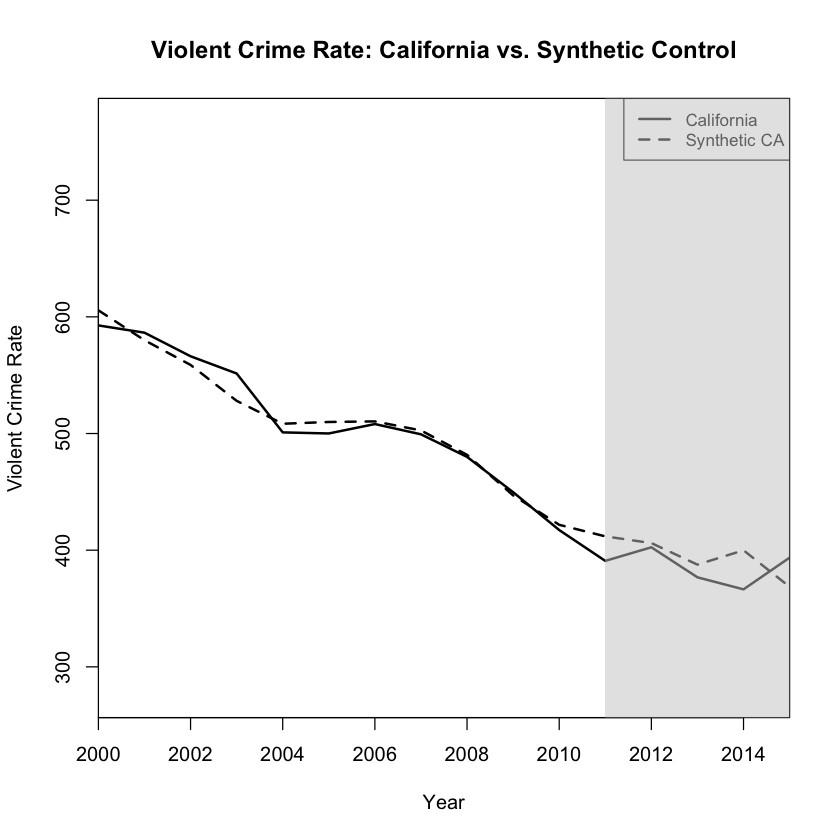

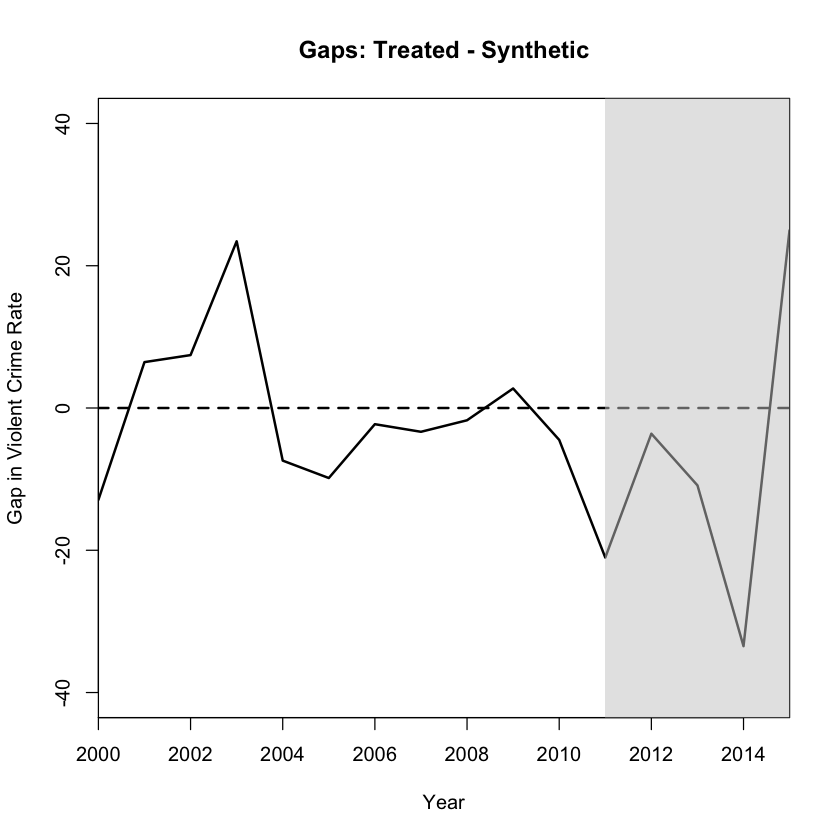

In [41]:
# Actual vs. Synthetic
path.plot(synth.res = synth.out, dataprep.res = dataprep.out,
          Ylab = "Violent Crime Rate", Xlab = "Year",
          Legend = c("California", "Synthetic CA"),
          Legend.position = "topright")

title("Violent Crime Rate: California vs. Synthetic Control")

# Add shaded treatment period: from 2011 to 2015
rect(xleft = 2011, xright = 2015.5, ybottom = par("usr")[3], ytop = par("usr")[4],
     col = rgb(0.8, 0.8, 0.8, 0.5), border = NA)

gaps.plot(synth.res = synth.out, dataprep.res = dataprep.out,
          Ylab = "Gap in Violent Crime Rate", Xlab = "Year")

# Add shaded treatment period
rect(xleft = 2011, xright = 2015.5, ybottom = par("usr")[3], ytop = par("usr")[4],
     col = rgb(0.8, 0.8, 0.8, 0.5), border = NA)

From just looking at the graph, it doesn't look like there's much of a difference between the synthetic California and real California in violent crime rates. If anything, it looks like it decreased slightly. 

#### Treatment Effect

In [42]:
# Actual California crime rate over time
Y_actual   <- dataprep.out$Y1plot

# Synthetic California crime rate over time
Y_synth    <- dataprep.out$Y0plot %*% synth.out$solution.w
# Full vector of gaps
gaps <- as.numeric(Y_actual - Y_synth)

years <- dataprep.out$tag$time.plot
treatment_effects <- data.frame(
  year = years,
  gap  = gaps
)
print(treatment_effects)

   year        gap
1  2000 -12.906085
2  2001   6.450607
3  2002   7.439004
4  2003  23.430960
5  2004  -7.397070
6  2005  -9.843844
7  2006  -2.274198
8  2007  -3.344699
9  2008  -1.725663
10 2009   2.742976
11 2010  -4.481698
12 2011 -21.021776
13 2012  -3.611258
14 2013 -10.874105
15 2014 -33.479732
16 2015  24.988931


In [43]:
# Identify indices corresponding to 2011–2015
post_idx <- which(years >= 2011 & years <= 2015)

# Subset the gaps
post_gaps <- gaps[post_idx]

# Compute the average treatment effect on the treated
ATE <- mean(post_gaps)

# the standard deviation
SD  <- sd(post_gaps)

cat("Average treatment effect (2011-2015):", round(ATE, 2),
    "+-", round(SD, 2), "crime rate units\n")


Average treatment effect (2011-2015): -8.8 +- 21.97 crime rate units


The average treatment effect (ATE) here refers to the average difference in violent crime rates between the real California and its synthetic version after the drought began, from 2011 to 2015. The estimated ATE is -8.8, meaning that each year from 2011 to 2015, California experienced 8.8 fewer violent crimes per 100,000 people on average, compared to what its synthetic counterpart predicted would have happened without the drought.

The standard error of 21.97 reflects the variability in the estimated gaps across the post-treatment period — it's a measure of how much the gaps fluctuate year to year after the drought started. 

This standard error is not tied to a traditional confidence interval. It only gives a sense of variability, it doesn’t tell us whether -8.8 is statistically significant.

### Property Crime Rate

In [44]:
dataprep.out_prop <- dataprep(
  foo = data_clean,
  
  predictors = c(
    "r15_19", "r20_24", "r25_29",
    "race_AIAN", "race_Asian", "race_Black", "race_HISPANIC", 
    "race_NHPI", "race_Multiple", "race_White",
    "PovertyPercentAllAges", "PovertyPercentAges017",
    "logmedian", "ipercapita", "gini", "jobspercapita", "unemprate_yr",
    "median_earnings", "manage_earnings", "service_earnings", 
    "sales_earnings", "construction_earnings",
    "pct_own_lt20_30pct_total", "pct_own_20_lt35_30pct_total", 
    "pct_own_35_lt50_30pct_total", "pct_own_50_lt75_30pct_total", 
    "pct_own_75pl_30pct_total",
    "pct_rent_lt20_30pct_total", "pct_rent_20_lt35_30pct_total", 
    "pct_rent_35_lt50_30pct_total", "pct_rent_50_lt75_30pct_total", 
    "pct_rent_75pl_30pct_total",
    "value_ratio_lt2", "value_ratio_2_3", "value_ratio_3_4", "value_ratio_gt4",
    "pct_samehouse", "pct_moved_outofstate", "pct_moved_abroad",
    "gas_price_gal", "totalemployees", "agencies", "maleofficers",
    "maxtemp"
  ),
  predictors.op           = "mean",
  time.predictors.prior   = 2000:2010,
  
  # from Table 1 in Goin et al.—the 2000–2010 average of the property‐crime rate
  special.predictors      = list(
    list("propertycrimerate", 2000:2010, "mean")
  ),
  
  dependent               = "propertycrimerate",
  unit.variable           = "state_id",
  unit.names.variable     = "state",
  time.variable           = "year",
  treatment.identifier    = ca_id,
  controls.identifier     = control_ids,
  time.optimize.ssr       = 2000:2010,
  time.plot               = 2000:2015
)



 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: gini ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for pre

In [45]:
synth.out_prop <- synth(dataprep.out_prop)



X1, X0, Z1, Z0 all come directly from dataprep object.


**************** 
 searching for synthetic control unit  
 

**************** 
**************** 
**************** 

MSPE (LOSS V): 4973.758 

solution.v:
 0.03940844 0.01284729 0.02922579 0.0002437932 0.04162123 0.01747217 0.06617059 0.08580398 0.04399159 0.01718457 0.003111609 0.002247636 0.01117462 0.009327729 0.05826817 0.001747798 0.01031989 0.001039854 0.001232615 0.007391543 0.0006602898 0.009893574 0.02886129 0.02248856 0.009225392 0.01862924 0.02121398 0.07433507 0.01962902 0.01142839 0.004388418 0.000428964 0.003055417 0.005253901 0.005524966 0.003650869 0.06856463 0.008588976 0.0002481867 0.04853291 0.04180921 0.03044857 0.008706186 0.06009136 0.03451172 

solution.w:
 1.95e-08 1.584e-07 2.33e-08 9.45e-08 1.631e-07 8.49e-08 1.355e-07 6.32e-08 5.51e-08 4.559e-07 3.1e-08 2.95e-08 7.01e-08 1.66e-08 3.82e-08 5.4e-09 1.4022e-06 2.469e-07 5.76e-08 1.229e-07 1.28e-08 3.84e-08 2.36e-08 4.19e-08 0.3812468 5.65e-08 4.2566e-06 1.

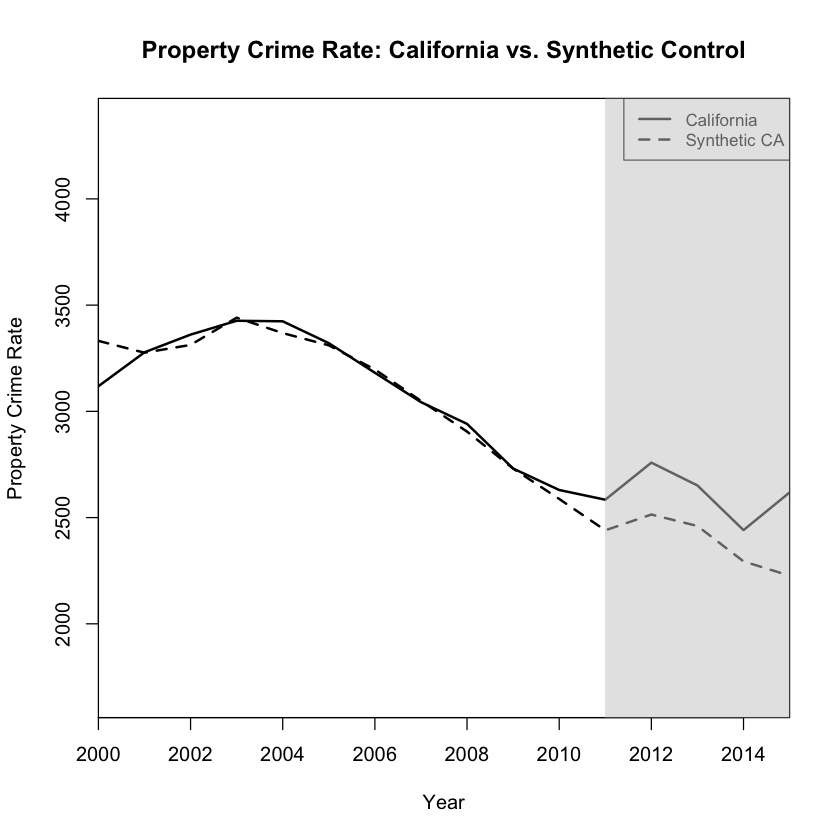

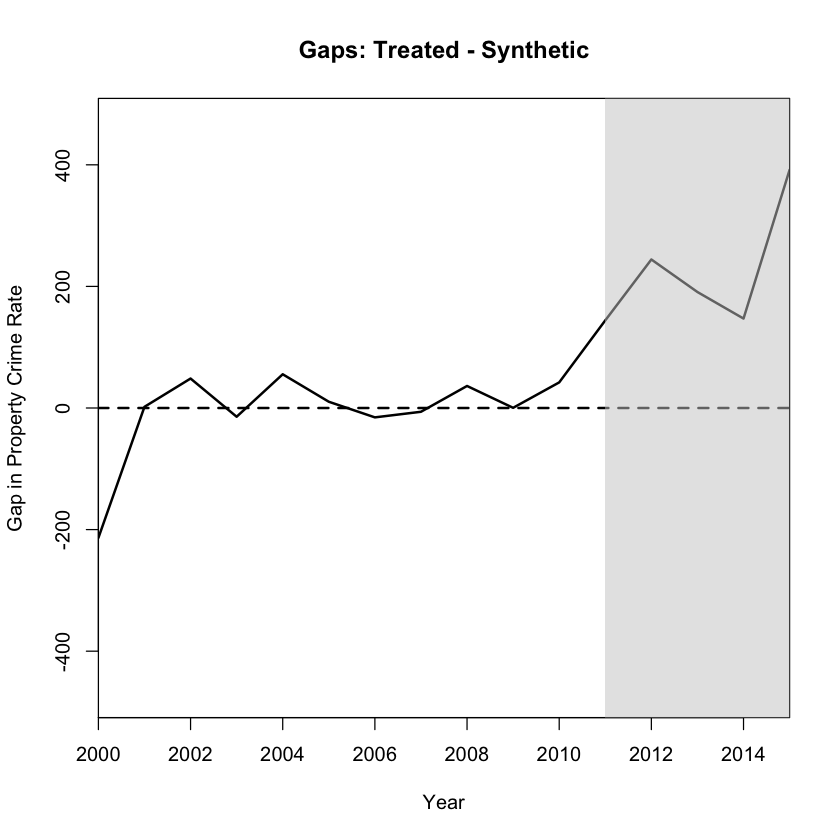

In [46]:
# Actual vs. Synthetic (Property Crime)
path.plot(synth.res = synth.out_prop, dataprep.res = dataprep.out_prop,
          Ylab = "Property Crime Rate", Xlab = "Year",
          Legend = c("California", "Synthetic CA"),
          Legend.position = "topright")
title("Property Crime Rate: California vs. Synthetic Control")
# Add shaded treatment period: from 2011 to 2015
rect(xleft = 2011, xright = 2015.5, ybottom = par("usr")[3], ytop = par("usr")[4],
     col = rgb(0.8, 0.8, 0.8, 0.5), border = NA)

# Gap (Actual – Synthetic)
gaps.plot(synth.res = synth.out_prop, dataprep.res = dataprep.out_prop,
          Ylab = "Gap in Property Crime Rate", Xlab = "Year")
rect(xleft = 2011, xright = 2015.5, ybottom = par("usr")[3], ytop = par("usr")[4],
     col = rgb(0.8, 0.8, 0.8, 0.5), border = NA)


#### Treatment Effects

In [47]:
# 1. Extract the actual and synthetic property crime rates
Y_actual_prop <- dataprep.out_prop$Y1plot  # California
Y_synth_prop  <- dataprep.out_prop$Y0plot %*% synth.out_prop$solution.w  # Synthetic California

# 2. Calculate yearly treatment effects (gaps)
gaps_prop <- as.numeric(Y_actual_prop - Y_synth_prop)

# 3. Get corresponding years
years_prop <- dataprep.out_prop$tag$time.plot

# 4. Create a dataframe for inspection
treatment_effects_prop <- data.frame(
  year = years_prop,
  gap  = gaps_prop
)

# 5. Filter to post-drought years and compute average treatment effect (ATE)
post_index <- which(years_prop >= 2011 & years_prop <= 2015)
post_gaps  <- gaps_prop[post_index]

# 6. Calculate ATE and standard deviation
ATE_prop <- mean(post_gaps)
SD_prop  <- sd(post_gaps)

# 7. Print results
cat("Average treatment effect on property crime (2011-2015):", 
    round(ATE_prop, 2), "+-", round(SD_prop, 2), "\n")

# 8. View yearly treatment effects
print(treatment_effects_prop)


Average treatment effect on property crime (2011-2015): 223.61 +- 102.39 
   year          gap
1  2000 -213.5555265
2  2001    1.9481487
3  2002   48.4589412
4  2003  -14.3686154
5  2004   55.4806392
6  2005   10.2887324
7  2006  -15.4173713
8  2007   -6.2021329
9  2008   36.2429456
10 2009    0.3034191
11 2010   42.1080218
12 2011  144.1231124
13 2012  244.2867526
14 2013  190.7880231
15 2014  147.1206611
16 2015  391.7317122


The average treatment effect is 223.61 with a standard error of 102.39, suggesting a significant post-drought increase in property crime rates. Between 2011 and 2015, California’s property crime rate was, on average, 223.61 incidents per 100,000 people higher each year than its synthetic control.
All post-treatment years show positive gaps, supporting the idea that the drought had a real impact. Interestingly, the graphs show an upward trend starting around 2009–2010—still within the pre-treatment period. This early deviation could mean the effects of the drought began before 2011, possibly due to anticipation of the drought already influencing behavior.


 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAllAges ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2001 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: PovertyPercentAges017 ; for period: 2002 
 We ignore (na.rm = TRUE) all missing values for predictors.op.

 Missing data- treated unit; predictor: gini ; for period: 2000 
 We ignore (na.rm = TRUE) all missing values for pre

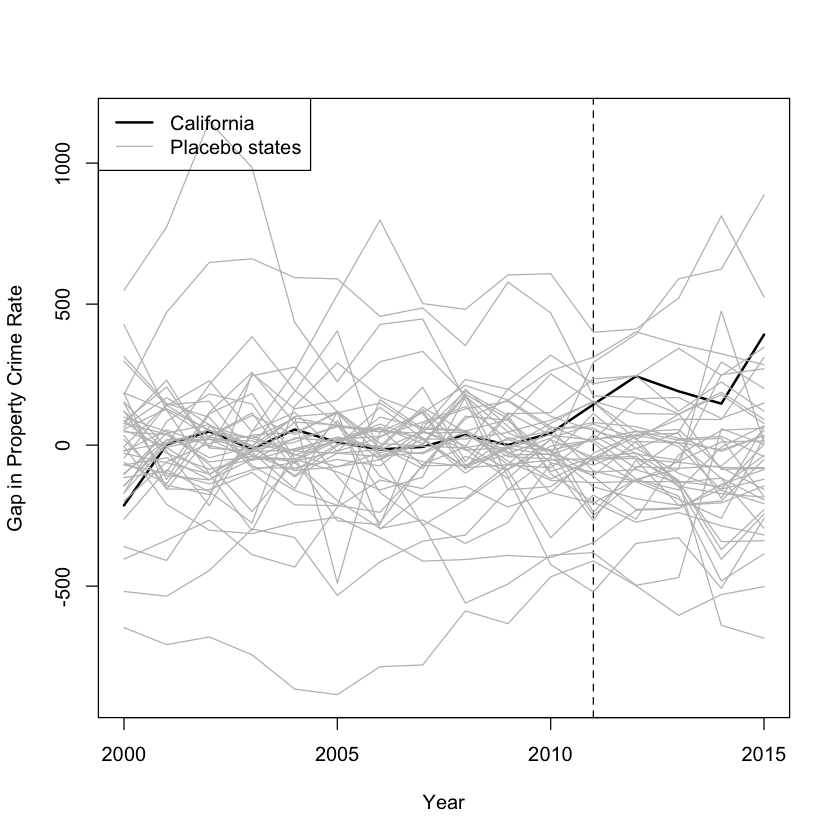

In [48]:
# 1) Predictor and special‐predictor lists 
predictor.vars <- c(
  "r15_19", "r20_24", "r25_29",
  "race_AIAN", "race_Asian", "race_Black", "race_HISPANIC",
  "race_NHPI", "race_Multiple", "race_White",
  "PovertyPercentAllAges", "PovertyPercentAges017",
  "logmedian", "ipercapita", "gini", "jobspercapita", "unemprate_yr",
  "median_earnings", "manage_earnings", "service_earnings",
  "sales_earnings", "construction_earnings",
  "pct_own_lt20_30pct_total","pct_own_20_lt35_30pct_total",
  "pct_own_35_lt50_30pct_total","pct_own_50_lt75_30pct_total",
  "pct_own_75pl_30pct_total",
  "pct_rent_lt20_30pct_total","pct_rent_20_lt35_30pct_total",
  "pct_rent_35_lt50_30pct_total","pct_rent_50_lt75_30pct_total",
  "pct_rent_75pl_30pct_total",
  "value_ratio_lt2","value_ratio_2_3","value_ratio_3_4","value_ratio_gt4",
  "pct_samehouse","pct_moved_outofstate","pct_moved_abroad",
  "gas_price_gal","totalemployees","agencies","maleofficers",
  "maxtemp"
)
special.list <- list(
  list("propertycrimerate", 2000:2010, "mean")
)

# 2) Build dataprep for CA
dataprep.out_prop <- dataprep(
  foo                   = data_clean,
  predictors            = predictor.vars,
  predictors.op         = "mean",
  time.predictors.prior = 2000:2010,
  special.predictors    = special.list,
  dependent             = "propertycrimerate",
  unit.variable         = "state_id",
  unit.names.variable   = "state",
  time.variable         = "year",
  treatment.identifier  = ca_id,
  controls.identifier   = control_ids,
  time.optimize.ssr     = 2000:2010,
  time.plot             = 2000:2015
)
synth.out_prop <- synth(dataprep.out_prop)

# 3) Extract CA gap once:
Y1_CA  <- dataprep.out_prop$Y1plot
Y0_CA  <- dataprep.out_prop$Y0plot %*% synth.out_prop$solution.w
gap_CA <- as.numeric(Y1_CA - Y0_CA)

# 4) Do the placebo loop, computing each control’s gap
placebo.gaps_prop <- lapply(control_ids, function(ctrl) {
  dp_ctrl <- dataprep(
    foo                   = data_clean,
    predictors            = predictor.vars,
    predictors.op         = "mean",
    time.predictors.prior = 2000:2010,
    special.predictors    = special.list,
    dependent             = "propertycrimerate",
    unit.variable         = "state_id",
    unit.names.variable   = "state",
    time.variable         = "year",
    treatment.identifier  = ctrl,
    controls.identifier   = setdiff(control_ids, ctrl),
    time.optimize.ssr     = 2000:2010,
    time.plot             = 2000:2015
  )
  so_ctrl <- synth(dp_ctrl)
  Y1_ctrl <- dp_ctrl$Y1plot
  Y0_ctrl <- dp_ctrl$Y0plot %*% so_ctrl$solution.w
  as.numeric(Y1_ctrl - Y0_ctrl)
})

# 5) Plot them all
years <- dataprep.out_prop$tag$time.plot

plot(years, gap_CA, type = "l", col = "black", lwd = 2,
     ylim = range(c(gap_CA, unlist(placebo.gaps_prop))),
     xlab = "Year", ylab = "Gap in Property Crime Rate")
abline(v = 2011, lty = 2)  # start of drought
for(g in placebo.gaps_prop) lines(years, g, col = "grey")
legend("topleft", legend = c("California", "Placebo states"),
       col = c("black","grey"), lty = 1, lwd = c(2,1))


The control states don't reflect pre-treatment period California well enough. 

Retaining 18/44 placebos (threshold = 9947.52)


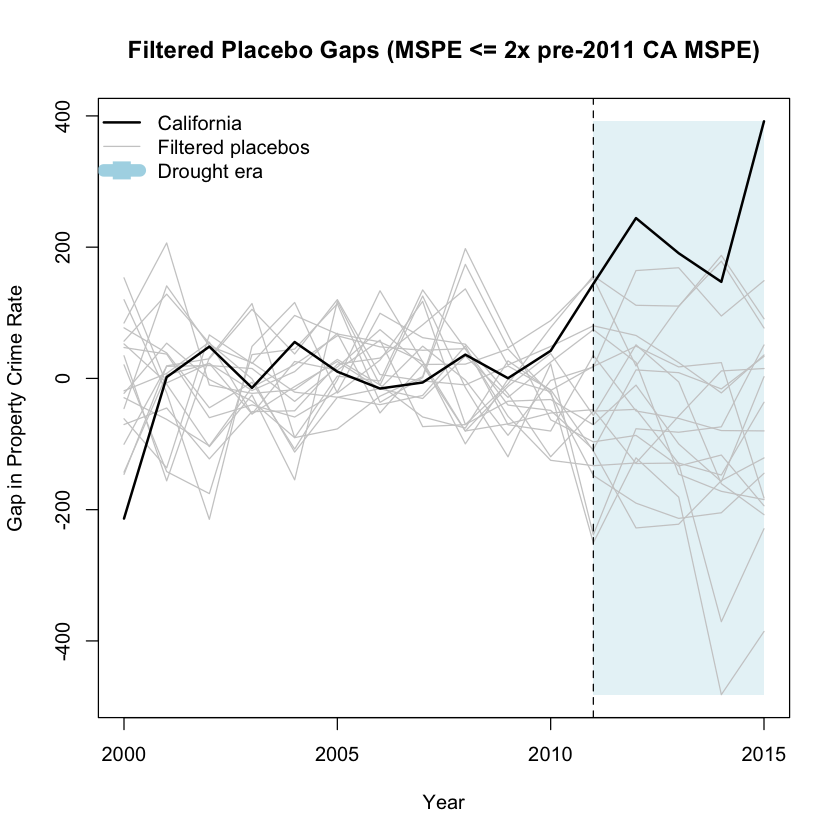

In [52]:
pre_idx   <- which(years <= 2010)
post_idx  <- which(years >  2010)
# California’s pre- and post-MSPE
mspe_ca_pre  <- mean( gap_CA[pre_idx]  ^2 )
mspe_ca_post <- mean( gap_CA[post_idx] ^2 )
ratio_ca     <- mspe_ca_post / mspe_ca_pre
# 1) Compute each placebo’s pre- and post-MSPE
mspe_placebo_pre  <- sapply(placebo.gaps_prop, function(g) mean(g[pre_idx]  ^2))
mspe_placebo_post <- sapply(placebo.gaps_prop, function(g) mean(g[post_idx] ^2))

# 1) compute each placebo’s pre‐2011 MSPE
mspe_placebo <- sapply(placebo.gaps_prop,
                       function(g) mean(g[pre_idx]^2))

# 2) select those with MSPE ≤ 2× CA’s
keep2     <- which(mspe_placebo <= 2* mspe_ca_pre)
filtered2 <- placebo.gaps_prop[keep2]

cat(sprintf("Retaining %d/%d placebos (threshold = %.2f)\n",
            length(filtered2), length(placebo.gaps_prop),
            2*mspe_ca_pre))

# 3) define y‐limits
y_lim2 <- range(c(gap_CA, unlist(filtered2)))

# 4) re‐plot
plot(
  years, gap_CA, type="n",
  xlim = range(years), ylim = y_lim2,
  xlab = "Year", ylab = "Gap in Property Crime Rate",
  main = "Filtered Placebo Gaps (MSPE <= 2x pre-2011 CA MSPE)"
)

# shade the drought era (2011 onward)
rect(2011, y_lim2[1], max(years), y_lim2[2],
     col = adjustcolor("lightblue", .3), border = NA)

# grey placebo lines
invisible(lapply(filtered2, function(g) {
  lines(years, g, col="grey80", lwd=1)
}))

# California line
lines(years, gap_CA, col="black", lwd=2)

# vertical line at start of drought
abline(v = 2011, lty=2)

legend("topleft",
       legend = c("California","Filtered placebos","Drought era"),
       col    = c("black","grey80","lightblue"),
       lwd    = c(2,1,10),
       pch    = c(NA,NA,15),
       pt.cex = c(NA,NA,2),
       bty    = "n")


By discarding any control state whose pre-2011 mean squared prediction error (MSPE) exceeds twice California’s, we’ve focused on 18 better-matched placebos. In the years 2000–2010, these filtered placebos (thin grey lines) cluster more tightly around zero. 
From 2011 onward (shaded in light blue), almost all of the filtered placebos remain around zero (with noise) or dip negative, whereas California’s gap shoots up sharply, reaching over +400 per 100 000 by 2015. This tells us that the post-drought increase in property crime is likely not an artifact of a few badly chosen controls. It points toward a genuine effect coinciding with the drought period. 

California shows the highest gap in the treatment period among the retained states, meaning no other control state experienced a larger divergence between actual and synthetic outcomes after the drought began. This implies a permutation-based p-value of 1/19, or approximately 0.053. The intuition is that if the treatment had no effect, California’s outcome should resemble that of the control states. So, the chance of it ranking first out of 19 by random chance is just 1 in 19.

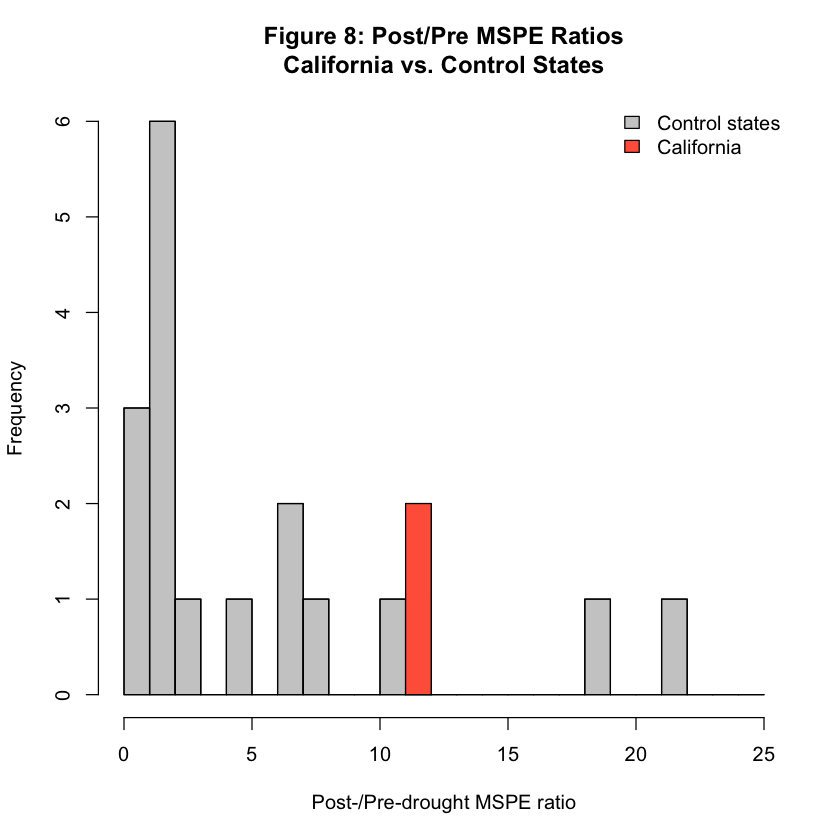

In [ ]:
# Compute ratio = post/pre
ratio_placebo <- mspe_placebo_post[keep2] / mspe_placebo_pre[keep2]


# Set up histogram bins to comfortably include CA’s ratio
all_ratios <- c(ratio_placebo, ratio_ca)
breaks     <- pretty(c(all_ratios, 25), n = 30)

# Plot histogram
h <- hist(ratio_placebo,
          breaks = breaks,
          border = "black",
          col    = "grey80",
          xlab   = "Post-/Pre-drought MSPE ratio",
          ylab   = "Frequency",
          main   = "Figure 8: Post/Pre MSPE Ratios\nCalifornia vs. Control States"
)

# Add California’s bar in a contrasting color
# Find which bin contains ratio_ca
bin_ca <- findInterval(ratio_ca, h$breaks, all.inside = TRUE)
# redraw that bin
rect(xleft   = h$breaks[bin_ca],
     ybottom = 0,
     xright  = h$breaks[bin_ca + 1],
     ytop    = h$counts[bin_ca] + 1,  # bump one extra to show CA
     col     = "tomato",
     border  = "black"
)
counts <- hist(ratio_placebo, breaks = breaks, plot = FALSE)$counts
counts[bin_ca] <- counts[bin_ca] + 1  # bump count by 1
rect(breaks[-length(breaks)], 0, breaks[-1], counts,
     col = ifelse(seq_along(counts)==bin_ca, "tomato", NA),
     border = "black"

legend("topright",
       legend = c("Control states", "California"),
       fill   = c("grey80",       "tomato"),
       border = "black",
       bty    = "n"
)



To assess the significance of the observed treatment effect, we compare California’s post-/pre-drought mean squared prediction error (MSPE) ratio to the distribution of ratios from placebo states. The MSPE quantifies how closely the synthetic control tracks the actual outcome, with higher values indicating a poorer fit. By computing MSPE separately for the pre-treatment (2000–2010) and post-treatment (2011–2015) periods and taking their ratio, we assess whether the model’s predictive accuracy deteriorated substantially after the onset of the drought.

California’s MSPE ratio stands out clearly from the rest of the distribution, with a value around 11—well above nearly all placebo states. This suggests that the synthetic control fit California closely prior to the drought, but diverged notably after 2011. The fact that very few placebo states exhibit larger ratios implies that the observed deviation in California is unlikely to have occurred by chance. This reinforces the interpretation that the drought may have had a real effect on property crime rates in California. However, it’s important to acknowledge that a few placebo states exhibit even higher post/pre-MSPE ratios. These outliers may reflect idiosyncratic events or poor synthetic matches in those states, rather than true treatment effects. 

The implied p-value from this figure is 3/19 or 0.158 since 2 placebo states (in addition to California) exhibited a post-/pre-drought MSPE ratio larger than California’s. This test evaluates how much worse the model’s fit becomes after the intervention, relative to how well it fit beforehand. It captures instability in the post-treatment period, rather than just the size of the treatment effect.

This differs from the previous result, where California had the largest raw post-treatment gap, resulting in a lower p-value of 0.053. In contrast, here, some placebo states may have had extremely tight pre-treatment fits and moderate post-treatment deviations—leading to a high ratio even if their actual gaps were smaller. So while California showed the strongest effect, it didn’t show the most extreme shift in model error, explaining the higher p-value.

AI Usage: I used ChatGPT to help me code and plot. I did not copy paste. 

Note: I uploaded a zip file only because when I export to pdf, the truncated outputs get printed in its entirety resulting in over 2000 pages, and they don't disappear even if I comment out the lines. 

# References

Abadie, A., Angrist, J., & Imbens, G. (2002). *Instrumental variables estimates of the effect of subsidized training on the quantiles of trainee earnings*. *Econometrica, 70*(1). https://doi.org/10.2307/2692164

Crommen, G. (n.d.). *GillesCrommen/DCC: R code for “An instrumental variable approach under dependent censoring.”* GitHub. Retrieved April 23, 2025, from https://github.com/GillesCrommen/DCC

Goin, D. E., Rudolph, K. E., & Ahern, J. (2017a). *Dataset for drought and crime synthetic control analysis, 2000–2015*. Figshare. https://doi.org/10.1371/u002Fjournal.pone.0185629.s001

Goin, D. E., Rudolph, K. E., & Ahern, J. (2017b). *Impact of drought on crime in California: A synthetic control approach*. *PLOS ONE, 12*(10), e0185629. https://doi.org/10.1371/journal.pone.0185629

NBER. (n.d.). *Index of /~rdehejia/data*. Retrieved April 23, 2025, from https://users.nber.org/~rdehejia/data/
